In [1]:
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.io import mmread, mmwrite

In [2]:
sys.path.append("../DALE_Eval/modules")

In [3]:
from pseudobulk import *
from visual_helpers import *

## BRCA_Bassez2021 

In [ ]:
# paper: https://www.nature.com/articles/s41591-021-01323-8
# raw data downloaded from: https://lambrechtslab.sites.vib.be/en/single-cell
# check ../scRNA_datasets/BRCA_Bassez2021/BRCA_Bassez2021_processing.ipynb for how scRNA dataset is processed

In [4]:
adata = sc.read_h5ad('../scRNA_datasets/BRCA_Bassez2021/BRCA_Bassez2021_processed.h5ad')

In [5]:
adata

AnnData object with n_obs × n_vars = 174287 × 20091
    obs: 'Cell', 'nCount_RNA', 'nFeature_RNA', 'patient_id', 'timepoint', 'expansion', 'BC_type', 'cellType', 'cohort', 'cell_type', 'sample'
    var: 'n_cells'

In [6]:
# separate sample collected at different timepoint to distinct sampleIDs
adata.obs['sampleID'] = (
    adata.obs['sample'].astype(str) + "_" + adata.obs['timepoint'].astype(str)
)

In [7]:
adata.obs['cell_type'].value_counts()

cell_type
T_cell              66352
Cancer_cell         38963
Fibroblast          29913
Myeloid_cell        16809
B_cell              10841
Endothelial_cell     9640
pDC                   896
Mast_cell             873
Name: count, dtype: int64

In [8]:
adata.obs.head()

,Cell,nCount_RNA,nFeature_RNA,patient_id,timepoint,expansion,BC_type,cellType,cohort,cell_type,sample,sampleID
1,BIOKEY_13_Pre_AAACCTGCAAGAAGAG-1,1252.0,700.0,BIOKEY_13,Pre,n/a,HER2+,T_cell,treatment_naive,T_cell,BIOKEY_13,BIOKEY_13_Pre
3,BIOKEY_13_Pre_AAACCTGTCAACGAAA-1,8454.0,2637.0,BIOKEY_13,Pre,n/a,HER2+,Myeloid_cell,treatment_naive,Myeloid_cell,BIOKEY_13,BIOKEY_13_Pre
4,BIOKEY_13_Pre_AAACGGGAGAGTAAGG-1,1612.0,874.0,BIOKEY_13,Pre,n/a,HER2+,Fibroblast,treatment_naive,Fibroblast,BIOKEY_13,BIOKEY_13_Pre
5,BIOKEY_13_Pre_AAACGGGCACAGAGGT-1,1908.0,916.0,BIOKEY_13,Pre,n/a,HER2+,Myeloid_cell,treatment_naive,Myeloid_cell,BIOKEY_13,BIOKEY_13_Pre
6,BIOKEY_13_Pre_AAACGGGCATGGGACA-1,5652.0,2290.0,BIOKEY_13,Pre,n/a,HER2+,Fibroblast,treatment_naive,Fibroblast,BIOKEY_13,BIOKEY_13_Pre


In [9]:
sample_col = "sampleID"
ct_col = "cell_type"
out_dir = "../Benchmarking_obj/BRCA_Bassez2021"

# Make folders
os.makedirs(os.path.join(out_dir, "bulk_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "frac_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "sumcount"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "meancpm"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "metadata"), exist_ok=True)

### truthfrac from scRNA

In [10]:
cellfrac = compute_cellfrac(adata.obs, sample_col=sample_col, ct_col=ct_col)
transcriptfrac = compute_transcriptfrac(adata, sample_col=sample_col, ct_col=ct_col)

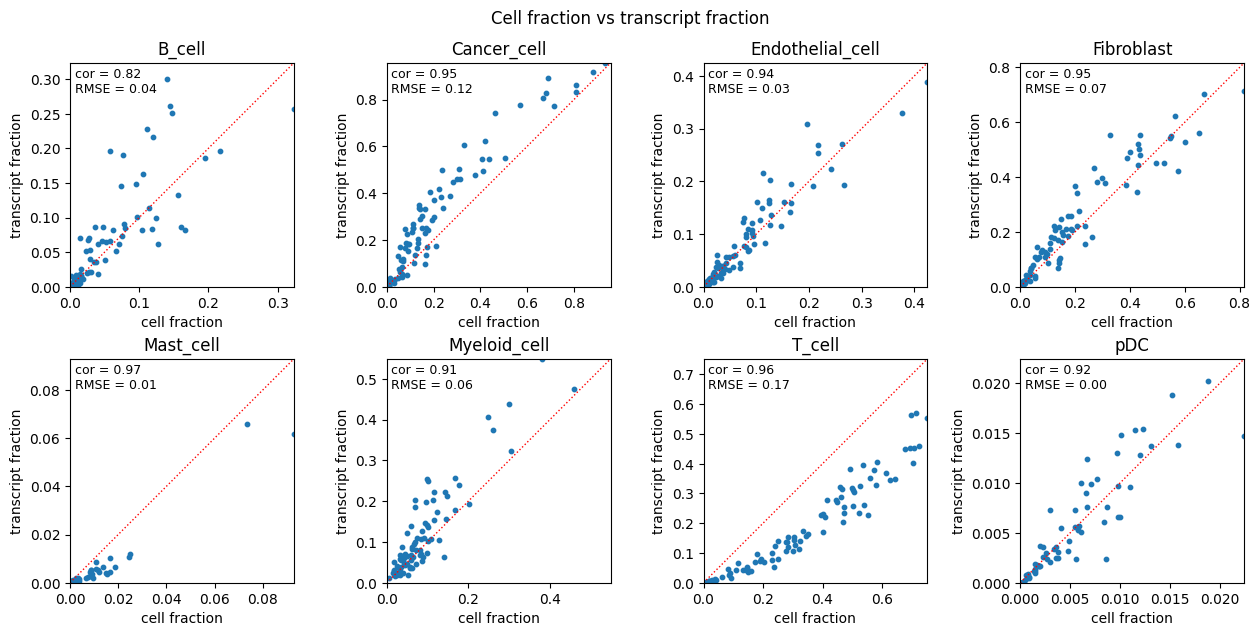

In [11]:
fig, summary, plot_data = plot_frac_comparison(
    cellfrac,
    transcriptfrac,
    title="Cell fraction vs transcript fraction",
    nrow=2,
    xlabel="cell fraction",
    ylabel="transcript fraction",
    return_data=True,
)

In [12]:
cellfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_cellfrac.txt"),sep="\t",)
transcriptfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_transcriptfrac.txt"),sep="\t",)

### pseudobulk from counts

In [13]:
# bulk samples from sum of counts
# note: transcriptfrac is a more relevant cell type frac estimate for this pseudobulk profile
bulk_sumcount = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=sample_col,
    pseudobulk_type="count",
)["pseudobulk"]

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
One-key mode: returning gene x sampleID DataFrame
Output pseudobulk shape: 20091 genes x 84 groups


In [14]:
bulk_sumcount

,BIOKEY_10_On,BIOKEY_10_Pre,BIOKEY_11_On,BIOKEY_11_Pre,BIOKEY_12_On,BIOKEY_12_Pre,BIOKEY_13_On,BIOKEY_13_Pre,BIOKEY_14_On,BIOKEY_14_Pre,...,BIOKEY_5_On,BIOKEY_5_Pre,BIOKEY_6_On,BIOKEY_6_Pre,BIOKEY_7_On,BIOKEY_7_Pre,BIOKEY_8_On,BIOKEY_8_Pre,BIOKEY_9_On,BIOKEY_9_Pre
A1BG,1530.0,687.0,978.0,444.0,1877.0,3519.0,171.0,552.0,308.0,652.0,...,187.0,505.0,800.0,1001.0,1954.0,1557.0,331.0,78.0,329.0,522.0
A1BG-AS1,312.0,127.0,131.0,36.0,190.0,242.0,22.0,102.0,29.0,82.0,...,20.0,87.0,92.0,128.0,118.0,68.0,45.0,17.0,32.0,71.0
A2M,4491.0,1807.0,1738.0,420.0,4432.0,4548.0,2455.0,3127.0,2304.0,2978.0,...,584.0,856.0,5043.0,5410.0,1168.0,425.0,211.0,293.0,1670.0,4477.0
A2M-AS1,104.0,26.0,24.0,7.0,64.0,78.0,17.0,37.0,8.0,33.0,...,12.0,57.0,30.0,46.0,34.0,3.0,12.0,0.0,11.0,27.0
A4GALT,217.0,168.0,70.0,13.0,457.0,470.0,170.0,375.0,158.0,255.0,...,57.0,69.0,646.0,584.0,405.0,86.0,7.0,11.0,161.0,291.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AL078612.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,6.0,8.0,14.0,21.0,0.0,0.0,4.0,2.0
AL590560.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,9.0,27.0,15.0,2.0,0.0,0.0,5.0,2.0
CCDC33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,8.0,10.0,9.0,4.0,0.0,0.0,0.0,15.0
OR4D1,0.0,0.0,23.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,5.0


In [27]:
bulk_sumcount.to_csv(os.path.join(out_dir, "bulk_input", "sumcount.txt"),sep="\t",)

In [15]:
# ctse_truth from sum of counts
ctse_sumcount_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="count",
)

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
Two-key mode: returning dict keyed by 'cell_type', with columns from 'sampleID'
Output contains 8 cell_type groups
Each matrix shape: 20091 genes x 84 sampleID groups


In [43]:
ctse_sumcount_res['pseudobulk']['Myeloid_cell']

,BIOKEY_13_Pre,BIOKEY_13_On,BIOKEY_10_Pre,BIOKEY_10_On,BIOKEY_16_Pre,BIOKEY_16_On,BIOKEY_14_Pre,BIOKEY_14_On,BIOKEY_19_Pre,BIOKEY_19_On,...,BIOKEY_40_Pre,BIOKEY_40_On,BIOKEY_37_Pre,BIOKEY_37_On,BIOKEY_34_Pre,BIOKEY_34_On,BIOKEY_39_Pre,BIOKEY_39_On,BIOKEY_42_Pre,BIOKEY_42_On
A1BG,29.0,14.0,49.0,240.0,144.0,430.0,36.0,10.0,75.0,42.0,...,14.0,70.0,82.0,40.0,17.0,294.0,0.0,75.0,13.0,28.0
A1BG-AS1,4.0,1.0,14.0,76.0,41.0,100.0,3.0,1.0,8.0,0.0,...,2.0,5.0,10.0,6.0,2.0,34.0,0.0,6.0,1.0,5.0
A2M,134.0,51.0,511.0,2590.0,1280.0,3075.0,101.0,32.0,481.0,582.0,...,8.0,155.0,87.0,297.0,80.0,524.0,7.0,993.0,18.0,327.0
A2M-AS1,1.0,2.0,6.0,17.0,10.0,30.0,2.0,0.0,3.0,0.0,...,1.0,2.0,0.0,1.0,0.0,10.0,0.0,3.0,0.0,2.0
A4GALT,1.0,0.0,0.0,2.0,1.0,11.0,2.0,0.0,0.0,2.0,...,0.0,1.0,0.0,0.0,0.0,16.0,0.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AL078612.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AL590560.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,7.0,0.0,9.0,0.0,0.0
CCDC33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OR4D1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0


In [35]:
# export ctse
for ct, mat in ctse_sumcount_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "sumcount", f"{ct}.txt.gz"),sep="\t",)

In [16]:
# Sanity check: bulk sumcount should equal the sum of CTSE sumcount across cell types
bulk_from_ctse = sum(ct_mat for ct_mat in ctse_sumcount_res["pseudobulk"].values())
bulk_from_ctse = bulk_from_ctse.loc[bulk_sumcount.index, bulk_sumcount.columns]
diff = bulk_sumcount.iloc[:5, :5] - bulk_from_ctse.iloc[:5, :5]
diff

,BIOKEY_10_On,BIOKEY_10_Pre,BIOKEY_11_On,BIOKEY_11_Pre,BIOKEY_12_On
A1BG,0.0,0.0,0.0,0.0,0.0
A1BG-AS1,0.0,0.0,0.0,0.0,0.0
A2M,0.0,0.0,0.0,0.0,0.0
A2M-AS1,0.0,0.0,0.0,0.0,0.0
A4GALT,0.0,0.0,0.0,0.0,0.0


In [ ]:
# export cpm normalized sumcount ctse
ctse_sumcount_cpm_dir = Path(out_dir) / "ctse_truth" / "sumcount_cpm"
ctse_sumcount_cpm_dir.mkdir(parents=True, exist_ok=True)

ctse_sumcount_cpm = normalize_ctse_sumcount_to_cpm(
    ctse_sumcount_res["pseudobulk"],
    target_sum=1e6,
)

ctse_sumcount_cpm_paths = {}
for ct, mat in ctse_sumcount_cpm.items():
    ct_path = ctse_sumcount_cpm_dir / f"{ct}.txt.gz"
    mat.to_csv(ct_path, sep="\t", float_format="%.2f")
    ctse_sumcount_cpm_paths[ct] = ct_path

### pseudobulk from cpm

In [17]:
# bulk samples from mean of cpm values per sample
# this is essential the same as a weighted sum of ctse cpm values, where weight is cellfrac
bulk_wcpm = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=sample_col,
    pseudobulk_type="cpm",
)["pseudobulk"]

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group


/home/humengying/miniforge3/envs/scVI/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


One-key mode: returning gene x sampleID DataFrame
Output pseudobulk shape: 20091 genes x 84 groups


In [18]:
bulk_wcpm

,BIOKEY_10_On,BIOKEY_10_Pre,BIOKEY_11_On,BIOKEY_11_Pre,BIOKEY_12_On,BIOKEY_12_Pre,BIOKEY_13_On,BIOKEY_13_Pre,BIOKEY_14_On,BIOKEY_14_Pre,...,BIOKEY_5_On,BIOKEY_5_Pre,BIOKEY_6_On,BIOKEY_6_Pre,BIOKEY_7_On,BIOKEY_7_Pre,BIOKEY_8_On,BIOKEY_8_Pre,BIOKEY_9_On,BIOKEY_9_Pre
A1BG,40.189771,42.200997,53.152062,53.326141,55.233905,92.980703,41.578974,54.663266,43.177671,47.934087,...,46.650168,39.474234,50.525373,40.046488,101.018379,87.523771,57.786202,47.670311,60.639025,45.349925
A1BG-AS1,9.389579,11.746331,7.884758,5.308347,7.602398,8.568780,5.298056,13.054384,4.234442,7.948017,...,5.531560,7.564014,5.798783,4.858463,7.028580,5.162635,8.572247,11.256789,6.166114,6.205659
A2M,71.345862,118.970254,49.782580,44.470650,98.189738,179.672062,559.404563,250.485113,435.552967,160.034888,...,117.156170,43.131100,290.392803,216.284806,90.960625,47.390444,27.126637,135.190186,297.439194,383.088110
A2M-AS1,4.709387,4.281902,2.338386,1.938608,3.760505,5.453276,5.388825,3.882655,2.587469,3.495192,...,5.308998,5.028570,1.710481,1.747538,2.625045,0.556724,2.403932,0.000000,2.452638,7.052737
A4GALT,4.152948,8.960734,2.444562,1.972647,8.100676,13.725063,30.263584,23.378965,18.848495,13.999589,...,12.129286,2.634166,30.316978,18.934702,23.942017,8.045579,1.648718,6.640001,25.062487,24.459194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AL078612.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.577752,0.159604,0.267101,1.090121,0.000000,0.000000,0.506174,0.269676
AL590560.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.393941,1.457127,0.673696,0.354464,0.000000,0.000000,1.397216,0.400152
CCDC33,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.335092,0.320643,0.359665,0.549446,0.000000,0.000000,0.000000,1.328238
OR4D1,0.000000,0.000000,1.927150,2.844116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.627959,0.000000,0.000000,0.000000,0.000000,0.000000,1.095658


In [27]:
bulk_wcpm.to_csv(os.path.join(out_dir, "bulk_input", "wcpm.txt"),sep="\t",float_format="%.2f",)

In [19]:
# ctse_truth from mean of cpm
ctse_meancpm_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="cpm",
)

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group
Two-key mode: returning dict keyed by 'cell_type', with columns from 'sampleID'
Output contains 8 cell_type groups
Each matrix shape: 20091 genes x 84 sampleID groups


In [28]:
# export ctse
for ct, mat in ctse_meancpm_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "meancpm", f"{ct}.txt.gz"),sep="\t",float_format="%.2f")

In [21]:
# Sanity check: bulk wcpm should equal the cell-fraction-weighted sum of CTSE meancpm across cell types
bulk_wcpm_from_ctse = compute_weighted_bulk_from_ct_profiles(ctse_meancpm_res["pseudobulk"], cellfrac,log2_transform=False,)
bulk_wcpm_from_ctse = bulk_wcpm_from_ctse.loc[bulk_wcpm.index,bulk_wcpm.columns,]
diff = bulk_wcpm.iloc[:5, :5] - bulk_wcpm_from_ctse.iloc[:5, :5]
diff # almost identical

,BIOKEY_10_On,BIOKEY_10_Pre,BIOKEY_11_On,BIOKEY_11_Pre,BIOKEY_12_On
A1BG,4.263256e-14,-2.842171e-14,-2.131628e-14,2.131628e-14,-2.131628e-14
A1BG-AS1,-3.552714e-15,-3.552714e-15,-1.776357e-15,0.000000e+00,-8.881784e-16
A2M,-7.105427e-14,-2.842171e-14,-2.131628e-14,-7.105427e-15,-8.526513e-14
A2M-AS1,0.000000e+00,8.881784e-16,4.440892e-16,-2.220446e-16,-1.332268e-15
A4GALT,1.776357e-15,1.776357e-15,0.000000e+00,0.000000e+00,-5.329071e-15


In [29]:
### optional: pseudobulk from weighted sum of log CTSE meancpm
# bulk_wlogcpm = compute_weighted_bulk_from_ct_profiles(ctse_meancpm_res["pseudobulk"],cellfrac,log2_transform=True,)
# bulk_wlogcpm.to_csv(os.path.join(out_dir, "bulk_input", "wlogcpm.txt"),sep="\t",float_format="%.2f")

### ctse truth comparison cpm vs sumcounts_cpm

In [5]:
ctse_sumcount_cpm = read_ctse_truth_dir(
    Path(out_dir) / "ctse_truth" / "sumcount_cpm"
)

ctse_meancpm = read_ctse_truth_dir(
    Path(out_dir) / "ctse_truth" / "meancpm"
)

ctse_cor = compute_ctse_gene_correlations(
    ctse_a_by_ct=ctse_sumcount_cpm,
    ctse_b_by_ct=ctse_meancpm,
    a_label="sumcount_cpm",
    b_label="meancpm",
    min_samples=3,
)

In [ ]:
# or
ctse_cor = compute_ctse_gene_correlations(
    ctse_a_by_ct=ctse_sumcount_cpm,
    ctse_b_by_ct=ctse_meancpm_res["pseudobulk"],
    a_label="sumcount_cpm",
    b_label="meancpm",
    min_samples=3,
)

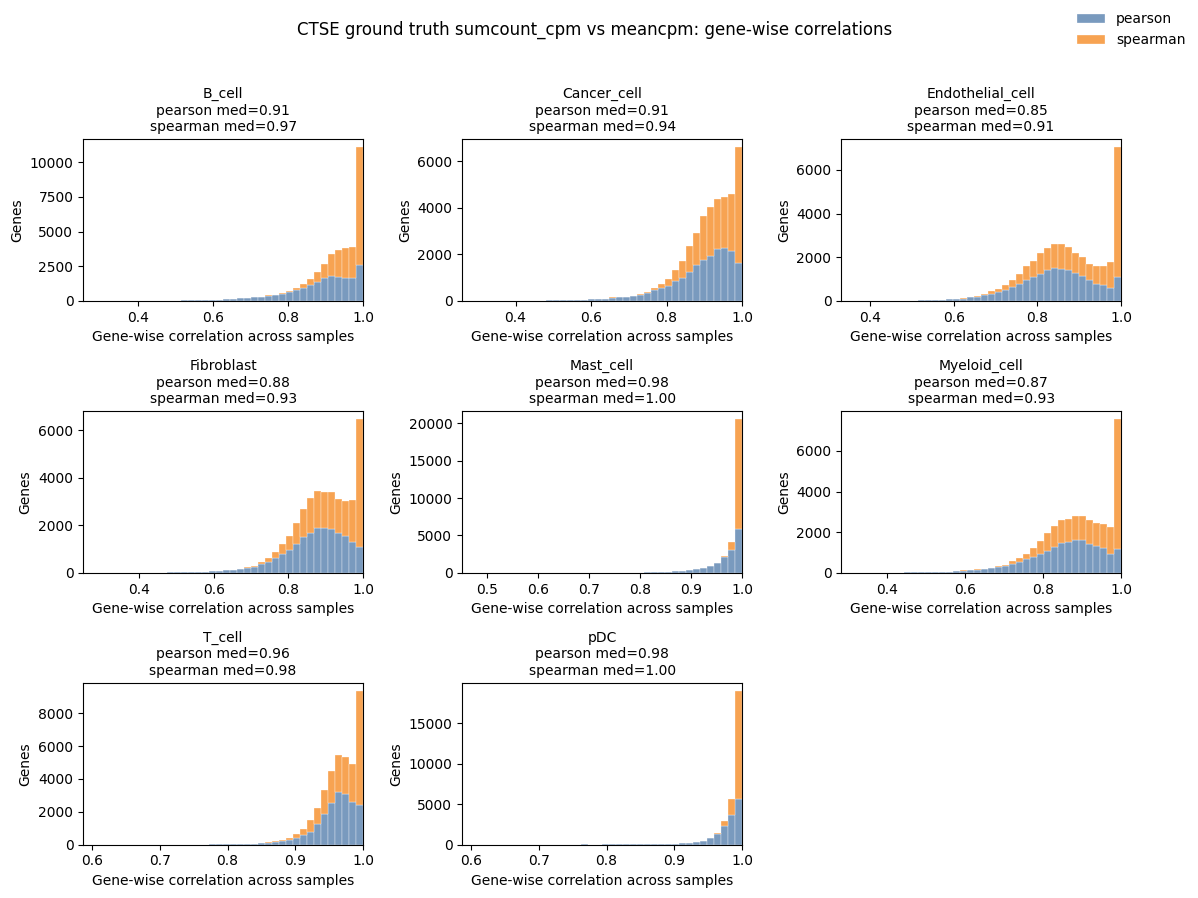

In [12]:
# Compare CTSE sumcount_cpm vs meancpm by gene-wise correlation across samples
fig = plot_ctse_gene_correlation_histograms(
    ctse_cor,
    metrics=("pearson", "spearman"),
    bins=40,
    ncol=3,
    title="CTSE ground truth sumcount_cpm vs meancpm: gene-wise correlations",
    stacked=True,
)

plt.show()

### metadata

In [42]:
sample_meta = adata.obs[['sampleID','sample','timepoint','expansion','BC_type','cohort']].drop_duplicates().copy()
n_cells = adata.obs["sampleID"].value_counts()
sample_meta["nCells"] = sample_meta["sampleID"].map(n_cells).astype(int)
sample_meta

,sampleID,sample,timepoint,expansion,BC_type,cohort,nCells
1,BIOKEY_13_Pre,BIOKEY_13,Pre,n/a,HER2+,treatment_naive,2884
3370,BIOKEY_13_On,BIOKEY_13,On,n/a,HER2+,treatment_naive,659
4244,BIOKEY_10_Pre,BIOKEY_10,Pre,E,TNBC,treatment_naive,2155
8884,BIOKEY_10_On,BIOKEY_10,On,E,TNBC,treatment_naive,5311
15037,BIOKEY_16_Pre,BIOKEY_16,Pre,E,TNBC,treatment_naive,3791
...,...,...,...,...,...,...,...
218680,BIOKEY_34_On,BIOKEY_34,On,NE,TNBC,neoadjuvant_chemo,2497
221678,BIOKEY_39_Pre,BIOKEY_39,Pre,NE,TNBC,neoadjuvant_chemo,360
222121,BIOKEY_39_On,BIOKEY_39,On,NE,TNBC,neoadjuvant_chemo,1631
224005,BIOKEY_42_Pre,BIOKEY_42,Pre,NE,ER+,neoadjuvant_chemo,484


In [ ]:
sample_meta.to_csv(os.path.join(out_dir, "metadata", "sample_meta.txt"),sep="\t",index=False,)

In [36]:
ctse_sumcount_res['pseudobulk_meta'].head()

,cell_type,sampleID,nCells
0,T_cell,BIOKEY_13_Pre,1553
1,T_cell,BIOKEY_13_On,330
2,T_cell,BIOKEY_10_Pre,1206
3,T_cell,BIOKEY_10_On,3731
4,T_cell,BIOKEY_16_Pre,2097


In [ ]:
ctse_sumcount_res['pseudobulk_meta'].to_csv(os.path.join(out_dir, "metadata", "ctse_meta.txt"),sep="\t",index=False,)

## CRC_Pelka2021

In [ ]:
# paper: https://www.sciencedirect.com/science/article/pii/S0092867421009454
# raw data downloaded from https://www.weizmann.ac.il/sites/3CA/colorectal
# refined cell type annotation from https://singlecell.broadinstitute.org/single_cell/study/SCP1162
# the following cell_types are removed because they present in too feww samples
# 'Epithelial','Granulocyte','ILC','Pericyte','Schwann','SmoothMuscle'
# 'Plasma' cell type are merged to 'B cell'
# after qc we have CRC_Pelka2021_processed.h5ad
# check ../scRNA_datasets/CRC_Pelka2021/CRC_Pelka2021_processing.ipynb for how scRNA is processed

In [4]:
adata = sc.read_h5ad('../scRNA_datasets/CRC_Pelka2021/CRC_Pelka2021_processed.h5ad')

In [5]:
adata

AnnData object with n_obs × n_vars = 167365 × 21582
    obs: 'sample', 'cell_type', 'cell_subtype', 'complexity', 'umap1', 'umap2', 'g1s_score', 'g2m_score', 'cell_cycle_phase', 'mp_top_score', 'mp_top', 'mp_assignment', 'sample_type', 'HistologicTypeSimple', 'MMR_IHC', 'MMRStatus', 'MLH1Status', 'MMRMLH1Tumor', 'TissueSite_detailed', 'TissueSiteSimple', 'HistologicGrade_detailed', 'HistologicGradeSimple', 'TumorStage', 'NodeStatus_detailed', 'NodeStatusSimple', 'MetastasisStatus', 'TumorSize', 'SizeQuantile', 'PID', 'Sex', 'Age', 'Ethnicity', 'Race', '3ca_group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'cell_type_3ca'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'

In [6]:
adata.obs.head()

,sample,cell_type,cell_subtype,complexity,umap1,umap2,g1s_score,g2m_score,cell_cycle_phase,mp_top_score,...,3ca_group,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,cell_type_3ca
cell_name,,,,,,,,,,,,,,,,,,,,,
C103_T_1_1_0_c1_v2_id-AAACCTGCATGCTAGT,C103_T,Malignant,cE01 (Stem/TA-like),2950,-22.0171,-15.7932,0.2582,0.0577,Not cycling,0.6014,...,1,2952,7.990577,15092,9.621986,22.767029,1151,7.049255,7.626557,Malignant
C103_T_1_1_0_c1_v2_id-AAACCTGGTTGTCGCG,C103_T,Malignant,cE03 (Stem/TA-like prolif),6509,-26.0861,-17.7857,1.6441,1.0115,G1/S,0.9133,...,1,6517,8.782323,50238,10.824547,20.771129,5629,8.635865,11.204666,Malignant
C103_T_1_1_0_c1_v2_id-AAACCTGTCATGTGGT,C103_T,Malignant,cE01 (Stem/TA-like),3357,-21.7427,-16.0377,0.0254,-0.0530,Not cycling,0.3965,...,1,3362,8.120589,16253,9.696094,23.257245,1764,7.475906,10.853381,Malignant
C103_T_1_1_0_c1_v2_id-AAACCTGTCCTTGGTC,C103_T,Malignant,cE01 (Stem/TA-like),6147,-23.9670,-17.9421,0.3143,0.0979,Not cycling,1.2349,...,1,6151,8.724533,42007,10.645615,20.772728,5010,8.519391,11.926584,Malignant
C103_T_1_1_0_c1_v2_id-AAACCTGTCGGATGTT,C103_T,T_cell,cTNI05 (CD4+ IL17+),897,NaN,NaN,NaN,NaN,NaN,NaN,...,1,898,6.801283,1937,7.569412,25.141972,189,5.247024,9.757357,T_cell


In [7]:
sample_col = "sample"
ct_col = "cell_type"
out_dir = "../Benchmarking_obj/CRC_Pelka2021"

# Make folders
os.makedirs(os.path.join(out_dir, "bulk_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "frac_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "sumcount"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "meancpm"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "metadata"), exist_ok=True)

### truthfrac from scRNA

In [8]:
cellfrac = compute_cellfrac(adata.obs, sample_col=sample_col, ct_col=ct_col)
transcriptfrac = compute_transcriptfrac(adata, sample_col=sample_col, ct_col=ct_col)

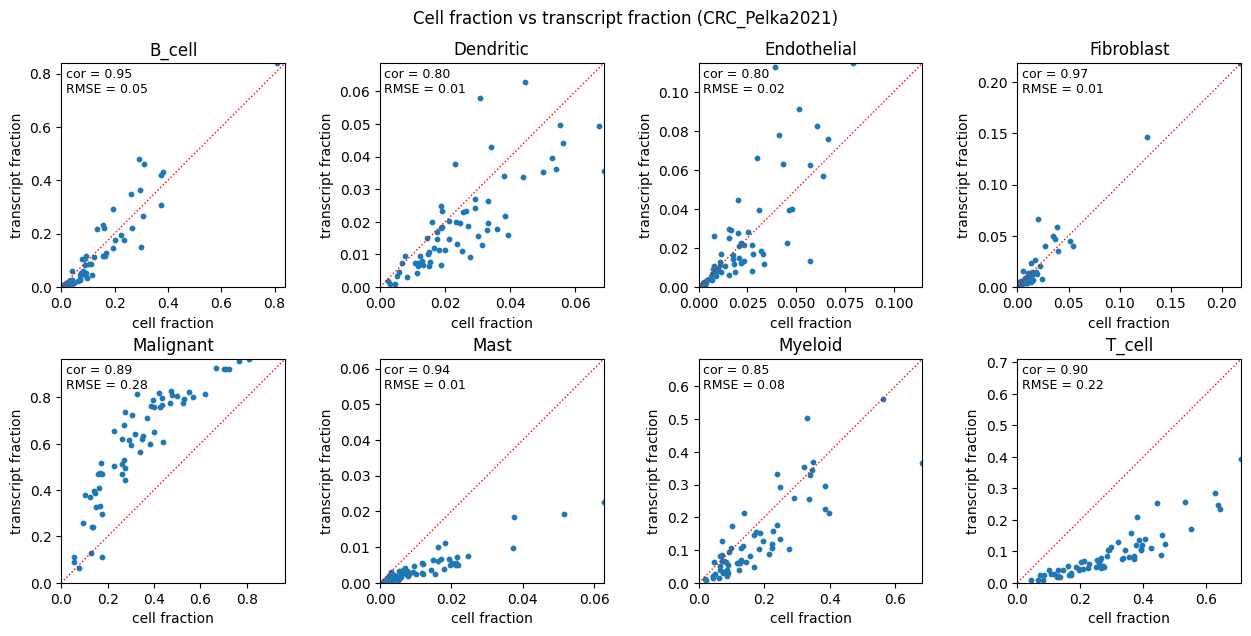

In [9]:
fig, summary, plot_data = plot_frac_comparison(
    cellfrac,
    transcriptfrac,
    title="Cell fraction vs transcript fraction (CRC_Pelka2021)",
    nrow=2,
    xlabel="cell fraction",
    ylabel="transcript fraction",
    return_data=True,
)

In [10]:
cellfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_cellfrac.txt"),sep="\t",)
transcriptfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_transcriptfrac.txt"),sep="\t",)

### pseudobulk from counts

In [11]:
bulk_sumcount = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=sample_col,
    pseudobulk_type="count",
)["pseudobulk"]

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
One-key mode: returning gene x sample DataFrame
Output pseudobulk shape: 21582 genes x 64 groups


In [12]:
bulk_sumcount.to_csv(os.path.join(out_dir, "bulk_input", "sumcount.txt"),sep="\t",)

In [13]:
# ctse_truth from sum of counts
ctse_sumcount_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="count",
)

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
Two-key mode: returning dict keyed by 'cell_type', with columns from 'sample'
Output contains 8 cell_type groups
Each matrix shape: 21582 genes x 64 sample groups


In [14]:
# export ctse
for ct, mat in ctse_sumcount_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "sumcount", f"{ct}.txt.gz"),sep="\t",)

In [15]:
# Sanity check: bulk sumcount should equal the sum of CTSE sumcount across cell types
bulk_from_ctse = sum(ct_mat for ct_mat in ctse_sumcount_res["pseudobulk"].values())
bulk_from_ctse = bulk_from_ctse.loc[bulk_sumcount.index, bulk_sumcount.columns]
diff = bulk_sumcount.iloc[:5, :5] - bulk_from_ctse.iloc[:5, :5]
diff

,C103_T,C104_T,C105_T,C106_T,C107_T
RP11-34P13.7,0.0,0.0,0.0,0.0,0.0
AL627309.1,0.0,0.0,0.0,0.0,0.0
AP006222.2,0.0,0.0,0.0,0.0,0.0
RP11-206L10.3,0.0,0.0,0.0,0.0,0.0
RP11-206L10.9,0.0,0.0,0.0,0.0,0.0


In [16]:
# export cpm normalized sumcount ctse
ctse_sumcount_cpm_dir = Path(out_dir) / "ctse_truth" / "sumcount_cpm"
ctse_sumcount_cpm_dir.mkdir(parents=True, exist_ok=True)

ctse_sumcount_cpm = normalize_ctse_sumcount_to_cpm(
    ctse_sumcount_res["pseudobulk"],
    target_sum=1e6,
)

ctse_sumcount_cpm_paths = {}
for ct, mat in ctse_sumcount_cpm.items():
    ct_path = ctse_sumcount_cpm_dir / f"{ct}.txt.gz"
    mat.to_csv(ct_path, sep="\t", float_format="%.2f")
    ctse_sumcount_cpm_paths[ct] = ct_path

### pseudobulk from cpm

In [17]:
# bulk samples from mean of cpm values per sample
# this is essential the same as a weighted sum of ctse cpm values, where weight is cellfrac
bulk_wcpm = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=sample_col,
    pseudobulk_type="cpm",
)["pseudobulk"]

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group


/home/humengying/miniforge3/envs/scVI/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


One-key mode: returning gene x sample DataFrame
Output pseudobulk shape: 21582 genes x 64 groups


In [18]:
bulk_wcpm

,C103_T,C104_T,C105_T,C106_T,C107_T,C109_T,C110_T,C111_T,C112_T,C113_T,...,C165_T,C166_T,C167_T,C168_T,C169_T,C170_T,C171_TA,C171_TB,C172_T,C173_T
RP11-34P13.7,0.323847,0.339819,0.074272,0.091654,0.212887,0.044321,0.413880,0.569995,0.028284,0.212810,...,0.475239,0.512625,0.084301,0.408669,0.018349,0.091901,0.234798,0.216008,0.185901,0.000000
AL627309.1,0.506481,1.766534,0.983295,3.084824,1.234568,1.427885,3.330808,2.424367,3.053636,3.095485,...,4.957119,6.101908,3.701337,2.503879,3.455883,4.554161,1.113964,1.287340,5.872004,3.929089
AP006222.2,12.628280,13.693677,10.872825,16.015310,12.966035,15.034736,14.218543,20.339350,27.418979,9.630000,...,15.485237,7.430879,8.085440,10.423391,9.795176,7.885167,2.577920,6.263672,10.443368,12.235405
RP11-206L10.3,0.410651,0.631190,0.788116,1.413837,0.664975,0.821736,0.735420,1.598475,0.891363,0.819721,...,3.765860,4.651204,3.090599,3.179641,2.900690,4.884880,1.810883,3.776775,6.227871,4.938307
RP11-206L10.9,2.426925,4.830077,4.748006,2.486875,4.751470,2.430157,2.725345,2.334015,2.482591,3.121205,...,4.336511,5.797747,5.451286,4.145072,6.310653,4.484391,5.379825,3.594702,2.331682,1.442967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CH17-408M7.1,0.000000,0.000000,0.000000,0.000000,0.021207,0.000000,0.000000,0.095032,0.031528,0.000000,...,0.108717,0.006328,0.000000,0.000000,0.000000,0.079049,0.000000,0.032893,0.000000,0.429972
CH507-39O4.2,0.199397,0.060127,0.030387,0.000000,0.108127,0.317586,0.038841,0.000000,0.229937,0.050500,...,0.006631,0.177164,0.237495,0.000000,0.016768,0.032034,0.013813,0.007578,0.000000,0.000000
CH507-338C24.1,2.581748,1.929230,2.808854,1.037608,2.644865,1.212787,1.228683,0.512047,1.811060,0.936346,...,1.213596,5.123053,1.601920,2.892326,1.078734,0.841634,0.824339,0.870504,2.231630,4.562719
CH507-254M2.3,2.254294,0.467680,1.803991,3.003158,1.358033,1.241062,2.087395,1.238965,1.310584,0.600587,...,0.724399,3.603180,0.365086,1.165338,0.357014,0.419822,0.562597,0.744316,0.938003,1.207008


In [19]:
bulk_wcpm.to_csv(os.path.join(out_dir, "bulk_input", "wcpm.txt"),sep="\t",float_format="%.2f",)

In [20]:
# ctse_truth from mean of cpm
ctse_meancpm_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="cpm",
)

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group
Two-key mode: returning dict keyed by 'cell_type', with columns from 'sample'
Output contains 8 cell_type groups
Each matrix shape: 21582 genes x 64 sample groups


In [21]:
# export ctse
for ct, mat in ctse_meancpm_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "meancpm", f"{ct}.txt.gz"),sep="\t",float_format="%.2f")

In [22]:
# Sanity check: bulk wcpm should equal the cell-fraction-weighted sum of CTSE meancpm across cell types
bulk_wcpm_from_ctse = compute_weighted_bulk_from_ct_profiles(ctse_meancpm_res["pseudobulk"], cellfrac,log2_transform=False,)
bulk_wcpm_from_ctse = bulk_wcpm_from_ctse.loc[bulk_wcpm.index,bulk_wcpm.columns,]
diff = bulk_wcpm.iloc[:5, :5] - bulk_wcpm_from_ctse.iloc[:5, :5]
diff # almost identical

,C103_T,C104_T,C105_T,C106_T,C107_T
RP11-34P13.7,5.551115e-17,5.551115e-17,0.000000e+00,1.387779e-17,0.000000e+00
AL627309.1,-1.110223e-16,2.220446e-16,1.110223e-16,4.440892e-16,-2.220446e-16
AP006222.2,0.000000e+00,1.776357e-15,1.776357e-15,0.000000e+00,0.000000e+00
RP11-206L10.3,0.000000e+00,1.110223e-16,-1.110223e-16,0.000000e+00,0.000000e+00
RP11-206L10.9,0.000000e+00,0.000000e+00,8.881784e-16,-4.440892e-16,8.881784e-16


### ctse truth comparison cpm vs sumcounts_cpm

In [23]:
ctse_cor = compute_ctse_gene_correlations(
    ctse_a_by_ct=ctse_sumcount_cpm,
    ctse_b_by_ct=ctse_meancpm_res["pseudobulk"],
    a_label="sumcount_cpm",
    b_label="meancpm",
    min_samples=3,
)

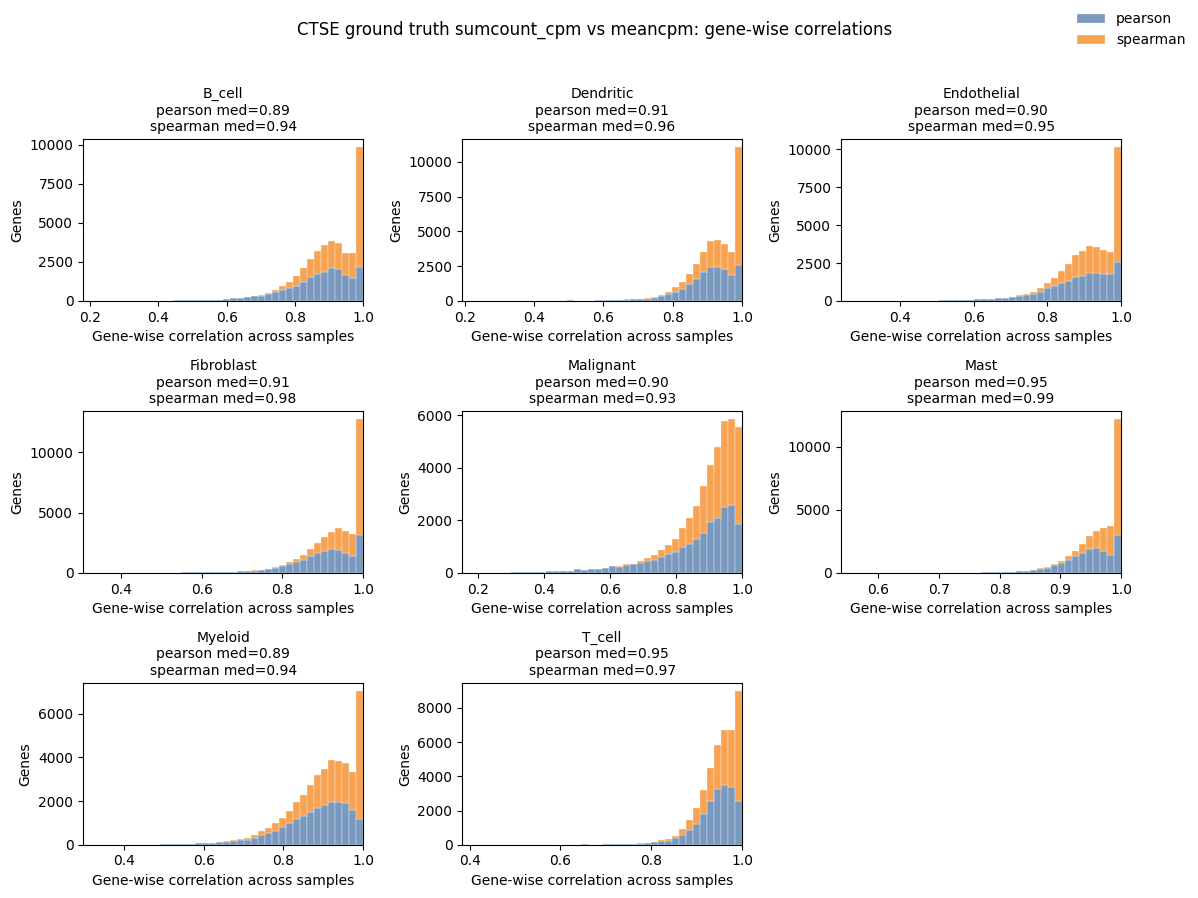

In [24]:
# Compare CTSE sumcount_cpm vs meancpm by gene-wise correlation across samples
fig = plot_ctse_gene_correlation_histograms(
    ctse_cor,
    metrics=("pearson", "spearman"),
    bins=40,
    ncol=3,
    title="CTSE ground truth sumcount_cpm vs meancpm: gene-wise correlations",
    stacked=True,
)

plt.show()

### metadata

In [25]:
cols = [
    "sample", "HistologicTypeSimple", "MMR_IHC",
    "MMRStatus", "MLH1Status", "MMRMLH1Tumor",
    "TissueSite_detailed", "TissueSiteSimple", "HistologicGrade_detailed",
    "HistologicGradeSimple", "TumorStage", "NodeStatus_detailed",
    "NodeStatusSimple", "MetastasisStatus", "TumorSize",
    "SizeQuantile", "PID", "Sex",
    "Age", "Ethnicity", "Race"
]
sample_meta = adata.obs[cols].drop_duplicates().copy()
n_cells = adata.obs["sample"].value_counts()
sample_meta["nCells"] = sample_meta["sample"].map(n_cells).astype(int)
sample_meta

,sample,HistologicTypeSimple,MMR_IHC,MMRStatus,MLH1Status,MMRMLH1Tumor,TissueSite_detailed,TissueSiteSimple,HistologicGrade_detailed,HistologicGradeSimple,...,NodeStatusSimple,MetastasisStatus,TumorSize,SizeQuantile,PID,Sex,Age,Ethnicity,Race,nCells
cell_name,,,,,,,,,,,,,,,,,,,,,
C103_T_1_1_0_c1_v2_id-AAACCTGCATGCTAGT,C103_T,Adenocarcinoma,preserved,MMRp,MLH1NoMeth,MMRp,LEFT colon (sigmoid colon),left,Low-grade (well differentiated to moderately d...,low,...,Nneg,not entered (Mx),2.5,1.0,C103,M,45,No,Asian,4697
C104_T_1_1_0_c1_v2_id-AAACCTGAGTACGCGA,C104_T,Adenocarcinoma,preserved,MMRp,MLH1NoMeth,MMRp,RIGHT colon (transverse),right,Low-grade (well differentiated to moderately d...,low,...,Nneg,not entered (Mx),4.0,2.0,C104,M,81,No,White,1199
C105_T_1_1_0_c1_v2_id-AAACCTGCAGACAAAT,C105_T,Adenocarcinoma,preserved,MMRp,MLH1NoMeth,MMRp,RIGHT colon (ascending colon),right,Low Grade (Well differentiated or Moderately d...,low,...,Npos,not entered (Mx),4.7,2.0,C105,M,71,No,White,2271
C106_T_1_1_0_c1_v2_id-AAACGGGAGTAGCGGT,C106_T,Adenocarcinoma;Mucinous,MLH1 and PMS2 deficient,MMRd,MLH1Meth,MMRd_MLH1Meth,RIGHT colon (cecum),right,Low Grade (Well differentiated or Moderately d...,low,...,Nneg,not entered (Mx),4.6,2.0,C106,M,67,No,White,1325
C107_T_1_1_0_c1_v2_id-AAACCTGCACAGACAG,C107_T,Adenocarcinoma,preserved,MMRp,MLH1NoMeth,MMRp,RIGHT colon (transverse),right,Low Grade (Moderately differentiated),low,...,Npos,not entered (Mx),8.2,4.0,C107,M,62,No,White,4140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C170_T_0_0_0_c1_v3_id-AAACCCAAGTCGGCCT,C170_T,Adenocarcinoma,MLH1 and PMS2 deficient,MMRd,MLH1Meth,MMRd_MLH1Meth,Right (ascending),right,Grade 2 (Moderately differntiated),low,...,Nneg,not entered (Mx),6.3,3.0,C170,F,77,No,Black or African American,4824
C171_TA_1_1_0_c1_v3_id-AAACCCAGTTGAGGAC,C171_TA,Adenocarcinoma,preserved,MMRp,MLH1NoMeth,MMRp,RIGHT colon,right,Grade 2 (Moderately differntiated),low,...,Nneg,not entered (Mx),3.2,1.0,C171,M,61,No,White,7640
C171_TB_1_1_0_c1_v3_id-AAACCCACAGACCCGT,C171_TB,Adenocarcinoma,preserved,MMRp,MLH1NoMeth,MMRp,RIGHT colon,right,Grade 2 (Moderately differntiated),low,...,Nneg,not entered (Mx),3.2,1.0,C171,M,61,No,White,2296


In [26]:
sample_meta.to_csv(os.path.join(out_dir, "metadata", "sample_meta.txt"),sep="\t",index=False,)

In [27]:
ctse_sumcount_res['pseudobulk_meta'].to_csv(os.path.join(out_dir, "metadata", "ctse_meta.txt"),sep="\t",index=False,)

## LUAD_Kim2020

In [5]:
# paper: https://www.sciencedirect.com/science/article/pii/S1535610822004998?via%3Dihub + https://www.nature.com/articles/s41467-020-16164-1
# combined lung data downloaded from cellxgene: https://cellxgene.cziscience.com/collections/edb893ee-4066-4128-9aec-5eb2b03f8287
# and selected dataset == 'Kim_Lee_2020'
# during preprocessing, the following modification is applied
# Macrophage/Monocyte renamed as 'Myeloid'
# cDC, pDC merged to 'Dentritic_cell'
# rename 'Stromal' as 'Fibroblast'
# relabel 'Epithelial cell' to 'Malignant' and 'Epithelial' based on 'cell_type_major' annotation
# replace all blank with '_'
# after qc we have LUAD_Kim2020_processed.h5ad

In [4]:
adata = sc.read_h5ad('../scRNA_datasets/LUAD_Kim2020/LUAD_Kim2020_processed.h5ad')

In [6]:
adata

AnnData object with n_obs × n_vars = 101733 × 16170
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'EGFR_mutation', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'cell_type_original'
    var: 'is_highly_variable', 'mito', 'n_cells

In [7]:
adata.var.head()

,is_highly_variable,mito,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,n_counts
ENSG00000121410,True,False,86866,2.527138,90.681054,2355657.0,False,A1BG,NCBITaxon:9606,gene,2134,protein_coding,14715.0
ENSG00000268895,True,False,12257,0.369194,98.685074,344142.0,False,A1BG-AS1,NCBITaxon:9606,gene,1667,lncRNA,1641.0
ENSG00000175899,True,False,122241,22.579874,86.886039,21047694.0,False,A2M,NCBITaxon:9606,gene,590,protein_coding,49204.0
ENSG00000245105,False,False,8827,0.172223,99.053043,160537.0,False,A2M-AS1,NCBITaxon:9606,gene,2551,lncRNA,1410.0
ENSG00000166535,True,False,5096,0.038011,99.453303,35432.0,False,A2ML1,NCBITaxon:9606,gene,592,protein_coding,171.0


In [8]:
adata.var_names = adata.var['feature_name'].astype(str)

In [9]:
(adata.var['feature_name'].duplicated()).sum()

np.int64(0)

In [11]:
adata.obs.head()

,sample,uicc_stage,ever_smoker,age,donor_id,origin,dataset,ann_fine,cell_type_predicted,doublet_status,...,cell_type,assay,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,cell_type_original
AAACCTGAGAAACGCC_NS_13-5,Kim_Lee_2020_NS_13,IV,yes,NaN,Kim_Lee_2020_P3013,tumor_metastasis,Kim_Lee_2020,Alveolar cell type 2,Epithelial cell malignant,singlet,...,Epithelial_cell,10x 3' v2,lung adenocarcinoma,Homo sapiens,female,brain,unknown,unknown,wFSEqguEz1,pulmonary alveolar type 2 cell
AAACCTGAGACGACGT_LUNG_T34-5,Kim_Lee_2020_LUNG_T34,I,no,NaN,Kim_Lee_2020_P0034,tumor_primary,Kim_Lee_2020,B cell,B cell,singlet,...,B_cell,10x 3' v2,lung adenocarcinoma,Homo sapiens,male,lung,unknown,unknown,)aG!2$VSLh,B cell
AAACCTGAGACGCTTT_LUNG_T18-5,Kim_Lee_2020_LUNG_T18,I,yes,NaN,Kim_Lee_2020_P0018,tumor_primary,Kim_Lee_2020,Cancer cells,Epithelial cell malignant,singlet,...,Malignant,10x 3' v2,lung adenocarcinoma,Homo sapiens,male,lung,unknown,unknown,Dpe^U$-Fc_,malignant cell
AAACCTGAGAGCAATT_EFFUSION_06-5,Kim_Lee_2020_EFFUSION_06,IV,yes,NaN,Kim_Lee_2020_P1006,tumor_metastasis,Kim_Lee_2020,T cell NK-like,T cell CD8,singlet,...,T_cell,10x 3' v2,lung adenocarcinoma,Homo sapiens,male,pleural effusion,unknown,unknown,pM2$l$rb&{,"CD8-positive, alpha-beta T cell"
AAACCTGAGAGGGATA_NS_19-5,Kim_Lee_2020_NS_19,IV,no,NaN,Kim_Lee_2020_P3019,tumor_metastasis,Kim_Lee_2020,Monocyte classical,Macrophage,singlet,...,Myeloid,10x 3' v2,lung adenocarcinoma,Homo sapiens,female,brain,unknown,unknown,fjEx=U#fsa,classical monocyte


In [12]:
sample_col = "sample"
ct_col = "cell_type"
out_dir = "../Benchmarking_obj/LUAD_Kim2020/"

# Make folders
os.makedirs(os.path.join(out_dir, "bulk_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "frac_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "sumcount"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "meancpm"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "metadata"), exist_ok=True)

### truthfrac from scRNA

In [13]:
cellfrac = compute_cellfrac(adata.obs, sample_col=sample_col, ct_col=ct_col)
transcriptfrac = compute_transcriptfrac(adata, sample_col=sample_col, ct_col=ct_col)

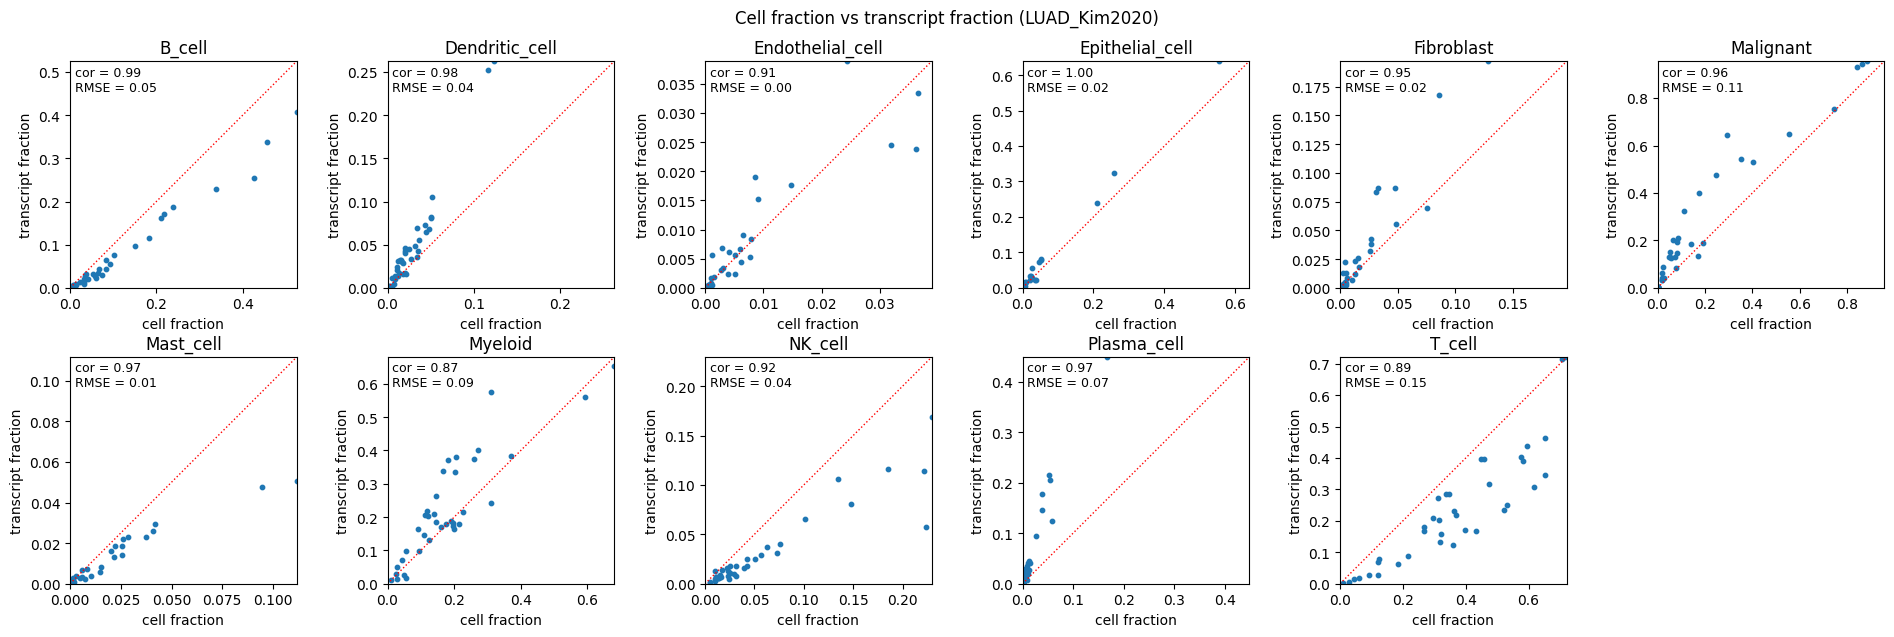

In [14]:
fig, summary, plot_data = plot_frac_comparison(
    cellfrac,
    transcriptfrac,
    title="Cell fraction vs transcript fraction (LUAD_Kim2020)",
    nrow=2,
    xlabel="cell fraction",
    ylabel="transcript fraction",
    return_data=True,
)

In [15]:
cellfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_cellfrac.txt"),sep="\t",)
transcriptfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_transcriptfrac.txt"),sep="\t",)

### pseudobulk from counts

In [16]:
bulk_sumcount = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=sample_col,
    pseudobulk_type="count",
)["pseudobulk"]

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
One-key mode: returning gene x sample DataFrame
Output pseudobulk shape: 16170 genes x 37 groups


In [17]:
bulk_sumcount.to_csv(os.path.join(out_dir, "bulk_input", "sumcount.txt"),sep="\t",)

In [18]:
# ctse_truth from sum of counts
ctse_sumcount_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="count",
)

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
Two-key mode: returning dict keyed by 'cell_type', with columns from 'sample'
Output contains 11 cell_type groups
Each matrix shape: 16170 genes x 37 sample groups


In [19]:
# export ctse
for ct, mat in ctse_sumcount_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "sumcount", f"{ct}.txt.gz"),sep="\t",)

In [20]:
# Sanity check: bulk sumcount should equal the sum of CTSE sumcount across cell types
bulk_from_ctse = sum(ct_mat for ct_mat in ctse_sumcount_res["pseudobulk"].values())
bulk_from_ctse = bulk_from_ctse.loc[bulk_sumcount.index, bulk_sumcount.columns]
diff = bulk_sumcount.iloc[:5, :5] - bulk_from_ctse.iloc[:5, :5]
diff

,Kim_Lee_2020_BRONCHO_11,Kim_Lee_2020_BRONCHO_58,Kim_Lee_2020_EBUS_06,Kim_Lee_2020_EBUS_10,Kim_Lee_2020_EBUS_12
A1BG,0.0,0.0,0.0,0.0,0.0
A1BG-AS1,0.0,0.0,0.0,0.0,0.0
A2M,0.0,0.0,0.0,0.0,0.0
A2M-AS1,0.0,0.0,0.0,0.0,0.0
A2ML1,0.0,0.0,0.0,0.0,0.0


In [ ]:
# export cpm normalized sumcount ctse
ctse_sumcount_cpm_dir = Path(out_dir) / "ctse_truth" / "sumcount_cpm"
ctse_sumcount_cpm_dir.mkdir(parents=True, exist_ok=True)

ctse_sumcount_cpm = normalize_ctse_sumcount_to_cpm(
    ctse_sumcount_res["pseudobulk"],
    target_sum=1e6,
)

ctse_sumcount_cpm_paths = {}
for ct, mat in ctse_sumcount_cpm.items():
    ct_path = ctse_sumcount_cpm_dir / f"{ct}.txt.gz"
    mat.to_csv(ct_path, sep="\t", float_format="%.2f")
    ctse_sumcount_cpm_paths[ct] = ct_path

### pseudobulk from cpm

In [21]:
bulk_wcpm = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=sample_col,
    pseudobulk_type="cpm",
)["pseudobulk"]

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group


/home/humengying/miniforge3/envs/scVI/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


One-key mode: returning gene x sample DataFrame
Output pseudobulk shape: 16170 genes x 37 groups


In [22]:
bulk_wcpm.to_csv(os.path.join(out_dir, "bulk_input", "wcpm.txt"),sep="\t",float_format="%.2f",)

In [23]:
# ctse_truth from mean of cpm
ctse_meancpm_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="cpm",
)

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group
Two-key mode: returning dict keyed by 'cell_type', with columns from 'sample'
Output contains 11 cell_type groups
Each matrix shape: 16170 genes x 37 sample groups


In [24]:
# export ctse
for ct, mat in ctse_meancpm_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "meancpm", f"{ct}.txt.gz"),sep="\t",float_format="%.2f")

In [25]:
# Sanity check: bulk wcpm should equal the cell-fraction-weighted sum of CTSE meancpm across cell types
bulk_wcpm_from_ctse = compute_weighted_bulk_from_ct_profiles(ctse_meancpm_res["pseudobulk"], cellfrac,log2_transform=False,)
bulk_wcpm_from_ctse = bulk_wcpm_from_ctse.loc[bulk_wcpm.index,bulk_wcpm.columns,]
diff = bulk_wcpm.iloc[:5, :5] - bulk_wcpm_from_ctse.iloc[:5, :5]
diff # almost identical

,Kim_Lee_2020_BRONCHO_11,Kim_Lee_2020_BRONCHO_58,Kim_Lee_2020_EBUS_06,Kim_Lee_2020_EBUS_10,Kim_Lee_2020_EBUS_12
A1BG,0.0,3.552714e-15,0.0,3.552714e-15,-3.552714e-15
A1BG-AS1,0.0,0.000000e+00,0.0,8.881784e-16,8.881784e-16
A2M,0.0,7.105427e-15,0.0,-8.881784e-16,0.000000e+00
A2M-AS1,0.0,8.881784e-16,0.0,0.000000e+00,2.220446e-16
A2ML1,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00


### ctse truth comparison cpm vs sumcounts_cpm

In [5]:
out_dir = "../Benchmarking_obj/LUAD_Kim2020/"

ctse_sumcount_cpm = read_ctse_truth_dir(
    Path(out_dir) / "ctse_truth" / "sumcount_cpm"
)

ctse_meancpm = read_ctse_truth_dir(
    Path(out_dir) / "ctse_truth" / "meancpm"
)

ctse_cor = compute_ctse_gene_correlations(
    ctse_a_by_ct=ctse_sumcount_cpm,
    ctse_b_by_ct=ctse_meancpm,
    a_label="sumcount_cpm",
    b_label="meancpm",
    min_samples=3,
)

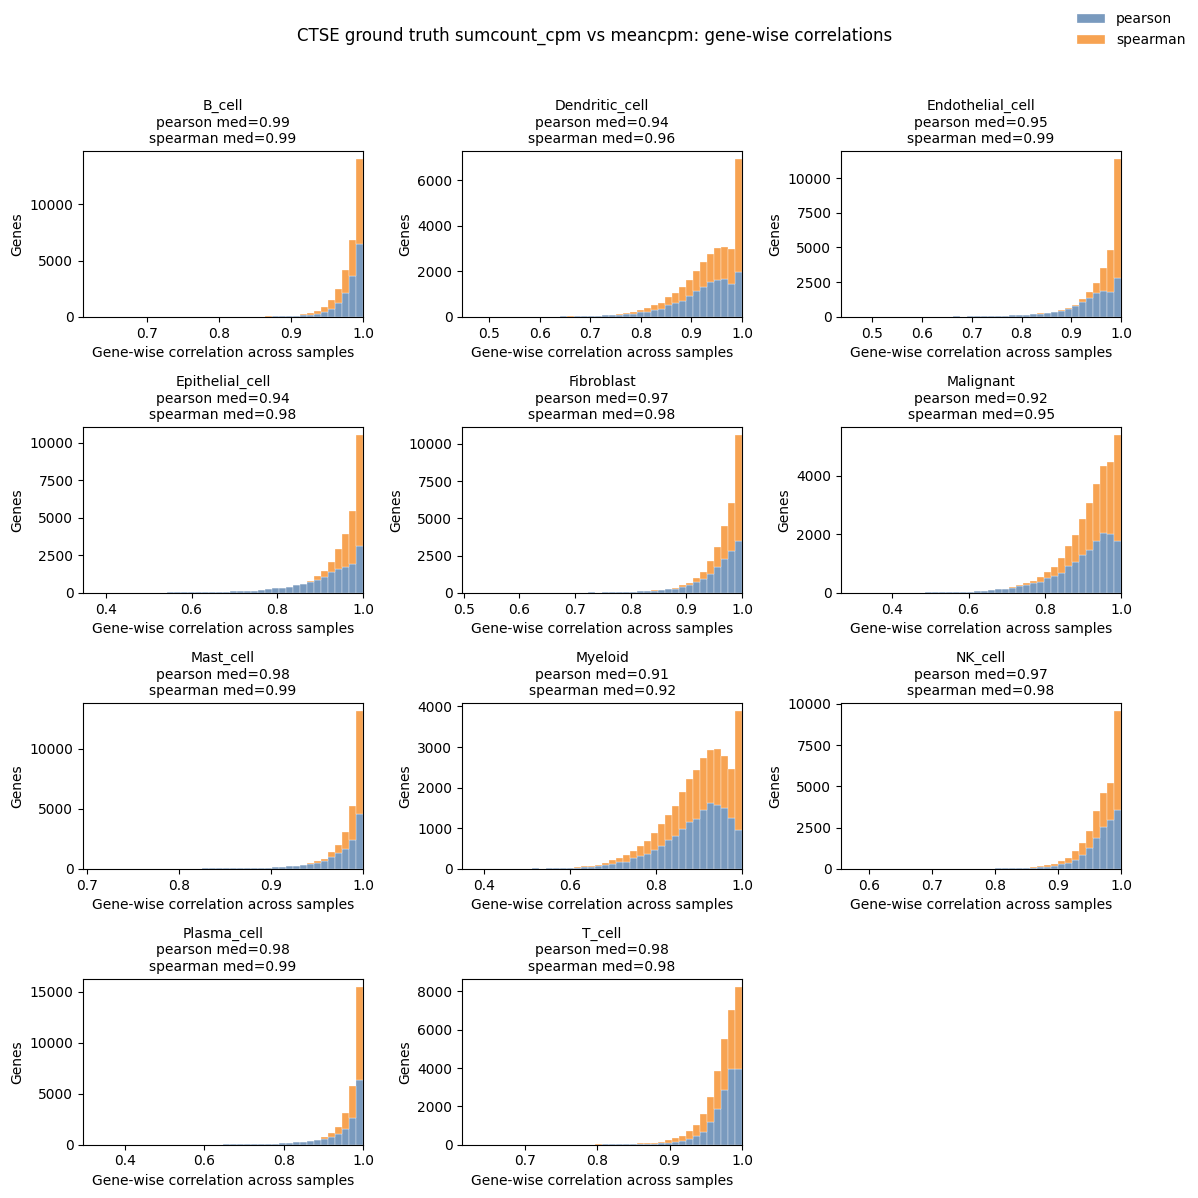

In [6]:
# Compare CTSE sumcount_cpm vs meancpm by gene-wise correlation across samples
fig = plot_ctse_gene_correlation_histograms(
    ctse_cor,
    metrics=("pearson", "spearman"),
    bins=40,
    ncol=3,
    title="CTSE ground truth sumcount_cpm vs meancpm: gene-wise correlations",
    stacked=True,
)

plt.show()

### metadata

In [33]:
cols = [
    "sample", "uicc_stage", "ever_smoker", "age",
    "donor_id", "origin", "origin_fine", "tumor_stage",
    "sex", "tissue", "self_reported_ethnicity"
]

sample_meta = adata.obs[cols].drop_duplicates().copy()
sample_meta = sample_meta.reset_index(drop = True)
sample_meta.head()

,sample,uicc_stage,ever_smoker,age,donor_id,origin,origin_fine,tumor_stage,sex,tissue,self_reported_ethnicity
0,Kim_Lee_2020_NS_13,IV,yes,NaN,Kim_Lee_2020_P3013,tumor_metastasis,tumor_metastasis,advanced,female,brain,unknown
1,Kim_Lee_2020_LUNG_T34,I,no,NaN,Kim_Lee_2020_P0034,tumor_primary,tumor_primary,early,male,lung,unknown
2,Kim_Lee_2020_LUNG_T18,I,yes,NaN,Kim_Lee_2020_P0018,tumor_primary,tumor_primary,early,male,lung,unknown
3,Kim_Lee_2020_EFFUSION_06,IV,yes,NaN,Kim_Lee_2020_P1006,tumor_metastasis,effusion,advanced,male,pleural effusion,unknown
4,Kim_Lee_2020_NS_19,IV,no,NaN,Kim_Lee_2020_P3019,tumor_metastasis,tumor_metastasis,advanced,female,brain,unknown


In [34]:
n_cells = adata.obs["sample"].value_counts()
sample_meta["nCells"] = sample_meta["sample"].map(n_cells).astype(int)
sample_meta

,sample,uicc_stage,ever_smoker,age,donor_id,origin,origin_fine,tumor_stage,sex,tissue,self_reported_ethnicity,nCells
0,Kim_Lee_2020_NS_13,IV,yes,NaN,Kim_Lee_2020_P3013,tumor_metastasis,tumor_metastasis,advanced,female,brain,unknown,3434
1,Kim_Lee_2020_LUNG_T34,I,no,NaN,Kim_Lee_2020_P0034,tumor_primary,tumor_primary,early,male,lung,unknown,2468
2,Kim_Lee_2020_LUNG_T18,I,yes,NaN,Kim_Lee_2020_P0018,tumor_primary,tumor_primary,early,male,lung,unknown,3135
3,Kim_Lee_2020_EFFUSION_06,IV,yes,NaN,Kim_Lee_2020_P1006,tumor_metastasis,effusion,advanced,male,pleural effusion,unknown,4488
4,Kim_Lee_2020_NS_19,IV,no,NaN,Kim_Lee_2020_P3019,tumor_metastasis,tumor_metastasis,advanced,female,brain,unknown,2426
5,Kim_Lee_2020_BRONCHO_11,IV,no,NaN,Kim_Lee_2020_P1011,tumor_metastasis,tumor_metastasis,advanced,female,lymph node,unknown,2672
6,Kim_Lee_2020_BRONCHO_58,IV,no,NaN,Kim_Lee_2020_P1058,tumor_primary,tumor_primary,advanced,female,lung,unknown,2403
7,Kim_Lee_2020_LUNG_T25,I,yes,NaN,Kim_Lee_2020_P0025,tumor_primary,tumor_primary,early,male,lung,unknown,3805
8,Kim_Lee_2020_EFFUSION_12,IV,no,NaN,Kim_Lee_2020_P1012,tumor_metastasis,effusion,advanced,female,pleural effusion,unknown,3733
9,Kim_Lee_2020_LUNG_T31,III,yes,NaN,Kim_Lee_2020_P0031,tumor_primary,tumor_primary,advanced,male,lung,unknown,4556


In [35]:
sample_meta.to_csv(os.path.join(out_dir, "metadata", "sample_meta.txt"),sep="\t",index=False,)

In [36]:
ctse_sumcount_res['pseudobulk_meta'].head()

,cell_type,sample,nCells
0,Epithelial_cell,Kim_Lee_2020_NS_13,890
1,Epithelial_cell,Kim_Lee_2020_LUNG_T34,1365
2,Epithelial_cell,Kim_Lee_2020_LUNG_T18,10
3,Epithelial_cell,Kim_Lee_2020_EFFUSION_06,0
4,Epithelial_cell,Kim_Lee_2020_NS_19,1


In [37]:
ctse_sumcount_res['pseudobulk_meta'].to_csv(os.path.join(out_dir, "metadata", "ctse_meta.txt"),sep="\t",index=False,)

## PBMC_1k1k (only cpm scRNA available)

In [ ]:
# https://onek1k.org/
# Only CPM-like scRNA is available for this dataset, so this section exports wcpm and meancpm CTSE only.
# Testing samples are selected from each benchmark object self_reference/sample_split.txt.

In [ ]:
from pathlib import Path
import sys

cwd = Path.cwd()
repo_root = cwd if (cwd / "DALE_Eval").exists() else cwd.parent
module_dir = repo_root / "DALE_Eval" / "modules"

if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from pseudobulk import (
    compute_cellfrac,
    build_ct_pseudobulk_profiles,
    compute_weighted_bulk_from_ct_profiles,
)


In [ ]:
pbmc_h5ad = Path("../../../InstaPrismExtension/scRNA_resource/PBMC/PBMC_1k1k/all.h5ad")

adata = sc.read_h5ad(pbmc_h5ad)
adata.obs["sample"] = "sample_" + adata.obs["indiv"].astype(str)

adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True,
    percent_top=[20],
    log1p=True,
)

In [6]:
adata

AnnData object with n_obs × n_vars = 822552 × 21128
    obs: 'id', 'majortype', 'celltype', 'ref_UMAP1', 'ref_UMAP2', 'nCount_RNA', 'nFeature_RNA', 'pool', 'batch', 'sex', 'age', 'indiv', 'cell_type'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'n_counts'
    obsm: 'X_pca', 'X_umap', 'harmpca'

In [ ]:
celltype_dict = {
    "T_cell": [
        "CD4 CTL", "CD4 Naive", "CD4 Proliferating", "CD4 TCM", "CD4 TEM", "Treg",
        "CD8 Naive", "CD8 Proliferating", "CD8 TCM", "CD8 TEM",
        "gdT",
    ],
    "B_cell": [
        "B intermediate", "B memory", "B naive", "Plasmablast",
    ],
    "Myeloid": [
        "CD14 Mono", "CD16 Mono", "cDC1", "cDC2", "ASDC",
    ],
    "NK": [
        "NK", "NK Proliferating", "NK_CD56bright",
    ],
}

ct_map_refined = {
    "CD4_T": [
        "CD4 CTL", "CD4 Naive", "CD4 Proliferating",
        "CD4 TCM", "CD4 TEM", "Treg",
    ],
    "CD8_T": [
        "CD8 Naive", "CD8 Proliferating",
        "CD8 TCM", "CD8 TEM",
    ],
    "gd_T": ["gdT"],
    "B_cell": [
        "B intermediate", "B memory", "B naive",
    ],
    "Plasma_B": ["Plasmablast"],
    "CD14_Mono": ["CD14 Mono"],
    "CD16_Mono": ["CD16 Mono"],
    "DC": [
        "cDC1", "cDC2", "ASDC",
    ],
    "NK": [
        "NK", "NK Proliferating", "NK_CD56bright",
    ],
}

coarse_lookup = {
    subtype: ct
    for ct, subtypes in celltype_dict.items()
    for subtype in subtypes
}

refined_lookup = {
    subtype: ct
    for ct, subtypes in ct_map_refined.items()
    for subtype in subtypes
}

adata.obs["cell_type_coarse"] = adata.obs["celltype"].map(coarse_lookup)
adata.obs["cell_type_refined"] = adata.obs["celltype"].map(refined_lookup)


In [ ]:
adata_processed = adata[
    (adata.obs["total_counts"] >= 1000)
    & (adata.obs["n_genes_by_counts"] >= 500)
    & (adata.obs["pct_counts_mt"] <= 20)
    & (~adata.obs["cell_type_coarse"].isna())
    & (~adata.obs["cell_type_refined"].isna()),
    adata.var["n_cells_by_counts"] >= 100,
].copy()

### PBMC_1k1k coarse cell types


In [ ]:
dataset_name = "PBMC_1k1k"
ct_col = "cell_type_coarse"

out_dir = repo_root / "Benchmarking_obj" / dataset_name
bulk_dir = out_dir / "bulk_input"
frac_dir = out_dir / "frac_input"
ctse_dir = out_dir / "ctse_truth" / "meancpm"
meta_dir = out_dir / "metadata"

for path in [bulk_dir, frac_dir, ctse_dir, meta_dir]:
    path.mkdir(parents=True, exist_ok=True)

sample_split = pd.read_csv(out_dir / "self_reference" / "sample_split.txt", sep="	")

test_samples = []
for value in sample_split.loc[
    sample_split["group"].astype(str).str.lower() == "test",
    "sampleIDs",
].astype(str):
    test_samples.extend([x.strip() for x in value.split(",") if x.strip()])

test_samples = sorted({
    s if s.startswith("sample_") else f"sample_{s}"
    for s in test_samples
})

adata_use = adata_processed[
    adata_processed.obs["sample"].isin(test_samples)
    & (~adata_processed.obs[ct_col].isna()),
    :
].copy()

present_samples = sorted(adata_use.obs["sample"].astype(str).unique())
missing_samples = sorted(set(test_samples) - set(present_samples))

In [ ]:
cellfrac = compute_cellfrac(
    adata_use.obs,
    sample_col="sample",
    ct_col=ct_col,
)
cellfrac = cellfrac.reindex(index=present_samples).fillna(0)

ctse_meancpm_res = build_ct_pseudobulk_profiles(
    adata_use,
    ct_group_keys=[ct_col, "sample"],
    pseudobulk_type="cpm",
    verbose=True,
)

bulk_wcpm = compute_weighted_bulk_from_ct_profiles(
    ctse_meancpm_res["pseudobulk"],
    cellfrac,
    log2_transform=False,
)

In [ ]:
bulk_wcpm.to_csv(
    bulk_dir / "wcpm.txt",
    sep="	",
    float_format="%.2f",
)

cellfrac.to_csv(
    frac_dir / "truth_cellfrac.txt",
    sep="	",
    float_format="%.6f",
)

for old_file in ctse_dir.glob("*.txt.gz"):
    old_file.unlink()

for ct, mat in ctse_meancpm_res["pseudobulk"].items():
    mat = mat.loc[:, present_samples]
    mat.to_csv(
        ctse_dir / f"{ct}.txt.gz",
        sep="	",
        float_format="%.2f",
    )

ctse_meancpm_res["pseudobulk_meta"].to_csv(
    meta_dir / "ctse_meta.txt",
    sep="	",
    index=False,
)

pd.Series(present_samples, name="sample").to_csv(
    meta_dir / "testing_samples_used.txt",
    sep="	",
    index=False,
)


### PBMC_refined_1k1k refined cell types


In [ ]:
dataset_name = "PBMC_refined_1k1k"
ct_col = "cell_type_refined"

out_dir = repo_root / "Benchmarking_obj" / dataset_name
bulk_dir = out_dir / "bulk_input"
frac_dir = out_dir / "frac_input"
ctse_dir = out_dir / "ctse_truth" / "meancpm"
meta_dir = out_dir / "metadata"

for path in [bulk_dir, frac_dir, ctse_dir, meta_dir]:
    path.mkdir(parents=True, exist_ok=True)

sample_split = pd.read_csv(out_dir / "self_reference" / "sample_split.txt", sep="	")

test_samples = []
for value in sample_split.loc[
    sample_split["group"].astype(str).str.lower() == "test",
    "sampleIDs",
].astype(str):
    test_samples.extend([x.strip() for x in value.split(",") if x.strip()])

test_samples = sorted({
    s if s.startswith("sample_") else f"sample_{s}"
    for s in test_samples
})

adata_use = adata_processed[
    adata_processed.obs["sample"].isin(test_samples)
    & (~adata_processed.obs[ct_col].isna()),
    :
].copy()

present_samples = sorted(adata_use.obs["sample"].astype(str).unique())
missing_samples = sorted(set(test_samples) - set(present_samples))


In [ ]:
cellfrac = compute_cellfrac(
    adata_use.obs,
    sample_col="sample",
    ct_col=ct_col,
)
cellfrac = cellfrac.reindex(index=present_samples).fillna(0)

ctse_meancpm_res = build_ct_pseudobulk_profiles(
    adata_use,
    ct_group_keys=[ct_col, "sample"],
    pseudobulk_type="cpm",
    verbose=True,
)

bulk_wcpm = compute_weighted_bulk_from_ct_profiles(
    ctse_meancpm_res["pseudobulk"],
    cellfrac,
    log2_transform=False,
)
bulk_wcpm = bulk_wcpm.loc[:, present_samples]


In [ ]:
bulk_wcpm.to_csv(
    bulk_dir / "wcpm.txt",
    sep="	",
    float_format="%.2f",
)

cellfrac.to_csv(
    frac_dir / "truth_cellfrac.txt",
    sep="	",
    float_format="%.6f",
)

for old_file in ctse_dir.glob("*.txt.gz"):
    old_file.unlink()

for ct, mat in ctse_meancpm_res["pseudobulk"].items():
    mat = mat.loc[:, present_samples]
    mat.to_csv(
        ctse_dir / f"{ct}.txt.gz",
        sep="	",
        float_format="%.2f",
    )

ctse_meancpm_res["pseudobulk_meta"].to_csv(
    meta_dir / "ctse_meta.txt",
    sep="	",
    index=False,
)

pd.Series(present_samples, name="sample").to_csv(
    meta_dir / "testing_samples_used.txt",
    sep="	",
    index=False,
)


## PBMC_Perez2022

In [ ]:
# paper: https://www.science.org/doi/10.1126/science.abf1970
# adata from cellxgene: https://cellxgene.cziscience.com/collections/436154da-bcf1-4130-9c8b-120ff9a888f2
# raw h5ad data from Martin
# the following filtering on raw h5ad is applied
# adata_processed = adata[
#    (adata.obs['cg_cov'].isin(['T4','cM','T8','B','NK','ncM','cDC','pDC','PB'])) &
#    (adata.obs['total_counts'] >= 1000) & 
#    (adata.obs['n_genes_by_counts'] >= 500) &
#    (adata.obs['pct_counts_mt'] <= 20)
#].copy()
# cell-type is being renames as follows
# celltype_coarse_dict = {
#    "B_cell": ["B",'PB'],
#    "T_cell": ["T4", "T8"],
#    "NK": ["NK"],
#    "Myeloid": ["cDC", "pDC",'cM','ncM']}

#celltype_refined_dict = {
#    "B_cell": ["B"],
#    "Plasma_B": 'PB',
#    "CD14_Mono": 'cM',
#    "CD16_Mono": 'ncM',
#    "CD4_T": "T4",
#    "CD8_T": "T8",
#    "DC": ["cDC", "pDC"],
#    "NK": ["NK"]}
# after qc we have PBMC_Perez2022_processed.h5ad

In [4]:
%%time
adata = sc.read_h5ad('../scRNA_datasets/PBMC_Perez2022/PBMC_Perez2022_processed.h5ad')

CPU times: user 1.58 s, sys: 4.15 s, total: 5.74 s
Wall time: 5.75 s


In [5]:
adata.shape

(1063788, 18863)

In [5]:
adata.obs.head()

,BatchL0_x,BatchL1_x,BatchL2_x,BatchL3_x,Prob(doublet),batch_cov,disease_cov,ind_cov,pop_cov,Genotype ID,...,total_counts,n_genes_by_counts,log1p_n_genes_by_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,cell_type_coarse,cell_type_refined
CAAGGCCAGTATCGAA-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-1-0-0-0-0-0,0.0,0.0,0.0,1.0,0.044088,dmx_YS-JY-22_pool6,Healthy,HC-546,Asian,HC-546,...,2134.0,670,6.508769,7.666222,31.490159,53.0,3.988984,2.483599,T_cell,CD4_T
AAGTCTGGTCTACCTC-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,0.0,0.0,1.0,0.0,0.040876,dmx_AbFlare-3,Flare,FLARE006,European,FLARE006,...,2583.0,1049,6.956545,7.857094,25.009679,112.0,4.727388,4.336043,Myeloid,CD14_Mono
GGCTCGATCGTTGACA-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-1-0-0-0-0-0-0-0-0-0-0,1.0,0.0,0.0,1.0,0.013999,dmx_YS-JY-20_pool3,Managed,1110_1110,European,1110_1110,...,1768.0,515,6.246107,7.478170,31.504525,76.0,4.343805,4.298643,B_cell,B_cell
ACACCGGCACACAGAG-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,1.0,0.0,0.0,0.0,0.019917,dmx_YE110,Managed,1479_1479,Asian,1479_1479,...,3079.0,799,6.684612,8.032685,32.867814,44.0,3.806663,1.429035,T_cell,CD4_T
TCGTAGATCCTTGGTC-1-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-1-0-0-0-0-0-0-0-0-0-0-0-0-0,1.0,0.0,0.0,1.0,0.014383,dmx_YE_8-2,Managed,1334_1334,Asian,1334_1334,...,1823.0,707,6.562444,7.508787,33.735601,216.0,5.379897,11.848601,T_cell,CD8_T


In [6]:
adata.obs['ind_cov'] = adata.obs['ind_cov'].str.replace('-', '_', regex=False)
adata.obs['sample'] = 'sample_' + adata.obs['ind_cov']

### PBMC_Perez2022 coarse cell types

In [8]:
sample_col = "sample"
ct_col = "cell_type_coarse"
out_dir = "../Benchmarking_obj/PBMC_Perez2022"

# Make folders
os.makedirs(os.path.join(out_dir, "bulk_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "frac_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "sumcount"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "meancpm"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "metadata"), exist_ok=True)

In [8]:
cellfrac = compute_cellfrac(adata.obs, sample_col=sample_col, ct_col=ct_col)
transcriptfrac = compute_transcriptfrac(adata, sample_col=sample_col, ct_col=ct_col)

In [10]:
cellfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_cellfrac.txt"),sep="\t",)
transcriptfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_transcriptfrac.txt"),sep="\t",)

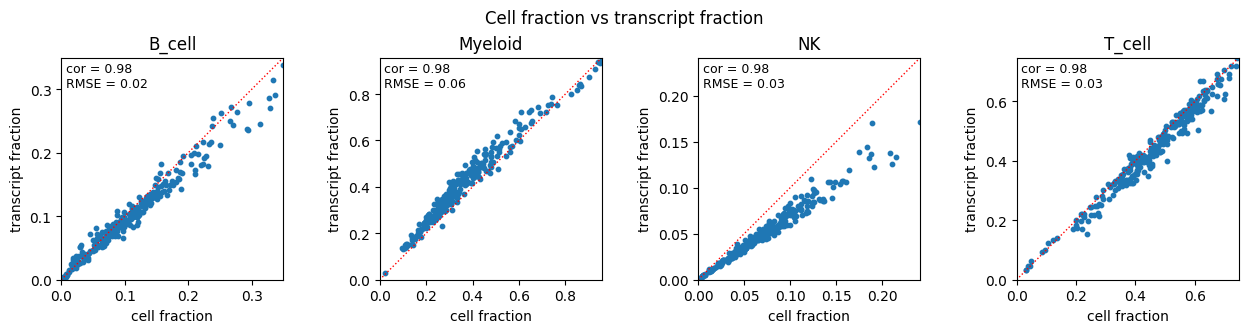

In [9]:
fig, summary, plot_data = plot_frac_comparison(
    cellfrac,
    transcriptfrac,
    title="Cell fraction vs transcript fraction",
    nrow=1,
    xlabel="cell fraction",
    ylabel="transcript fraction",
    return_data=True,
)

In [11]:
# bulk samples from sum of counts
# note: transcriptfrac is a more relevant cell type frac estimate for this pseudobulk profile
bulk_sumcount = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=sample_col,
    pseudobulk_type="count",
)["pseudobulk"]

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
One-key mode: returning gene x sample DataFrame
Output pseudobulk shape: 18863 genes x 261 groups


In [12]:
bulk_sumcount

,sample_1004_1004,sample_1014_1014,sample_1015_1015,sample_1019_1019,sample_1022_1022,sample_1031_1031,sample_1039_1039,sample_1045_1045,sample_1046_1046,sample_1051_1051,...,sample_IGTB256_IGTB256,sample_IGTB469_IGTB469,sample_IGTB498_IGTB498,sample_IGTB508_IGTB508,sample_IGTB514_IGTB514,sample_IGTB645_IGTB645,sample_IGTB670_IGTB670,sample_IGTB826_IGTB826,sample_IGTB884_IGTB884,sample_IGTB986_IGTB986
RP11-34P13.7,2.0,1.0,0.0,1.0,2.0,3.0,0.0,4.0,6.0,0.0,...,4.0,9.0,3.0,9.0,10.0,3.0,5.0,3.0,3.0,7.0
AL627309.1,20.0,22.0,8.0,14.0,22.0,14.0,5.0,34.0,18.0,21.0,...,50.0,72.0,48.0,71.0,72.0,66.0,48.0,73.0,40.0,62.0
AP006222.2,42.0,75.0,47.0,61.0,49.0,58.0,32.0,66.0,54.0,30.0,...,127.0,261.0,137.0,175.0,182.0,110.0,112.0,184.0,77.0,183.0
RP4-669L17.10,3.0,4.0,5.0,3.0,3.0,2.0,1.0,4.0,3.0,4.0,...,2.0,21.0,6.0,7.0,9.0,6.0,10.0,10.0,10.0,10.0
RP5-857K21.4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,4.0,0.0,0.0,1.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC011841.1,0.0,8.0,1.0,5.0,6.0,0.0,2.0,1.0,3.0,2.0,...,25.0,14.0,11.0,25.0,14.0,7.0,16.0,8.0,14.0,12.0
AL354822.1,13.0,6.0,7.0,21.0,4.0,3.0,3.0,1.0,3.0,7.0,...,3.0,12.0,36.0,15.0,32.0,14.0,12.0,34.0,10.0,17.0
KIR2DL2,21.0,4.0,2.0,20.0,22.0,0.0,5.0,52.0,8.0,8.0,...,18.0,175.0,18.0,90.0,36.0,49.0,47.0,11.0,20.0,38.0
PNRC2-1,25.0,46.0,61.0,4.0,39.0,7.0,26.0,3.0,36.0,42.0,...,7.0,26.0,13.0,17.0,20.0,18.0,64.0,181.0,2.0,8.0


In [13]:
bulk_sumcount.to_csv(os.path.join(out_dir, "bulk_input", "sumcount.txt"),sep="\t",)

In [15]:
# ctse_truth from sum of counts
ctse_sumcount_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="count",
)

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
Two-key mode: returning dict keyed by 'cell_type_coarse', with columns from 'sample'
Output contains 4 cell_type_coarse groups
Each matrix shape: 18863 genes x 261 sample groups


In [16]:
# export ctse
for ct, mat in ctse_sumcount_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "sumcount", f"{ct}.txt.gz"),sep="\t",)

In [17]:
# Sanity check: bulk sumcount should equal the sum of CTSE sumcount across cell types
bulk_from_ctse = sum(ct_mat for ct_mat in ctse_sumcount_res["pseudobulk"].values())
bulk_from_ctse = bulk_from_ctse.loc[bulk_sumcount.index, bulk_sumcount.columns]
diff = bulk_sumcount.iloc[:5, :5] - bulk_from_ctse.iloc[:5, :5]
diff

,sample_1004_1004,sample_1014_1014,sample_1015_1015,sample_1019_1019,sample_1022_1022
RP11-34P13.7,0.0,0.0,0.0,0.0,0.0
AL627309.1,0.0,0.0,0.0,0.0,0.0
AP006222.2,0.0,0.0,0.0,0.0,0.0
RP4-669L17.10,0.0,0.0,0.0,0.0,0.0
RP5-857K21.4,0.0,0.0,0.0,0.0,0.0


In [18]:
# export cpm normalized sumcount ctse
ctse_sumcount_cpm_dir = Path(out_dir) / "ctse_truth" / "sumcount_cpm"
ctse_sumcount_cpm_dir.mkdir(parents=True, exist_ok=True)

ctse_sumcount_cpm = normalize_ctse_sumcount_to_cpm(
    ctse_sumcount_res["pseudobulk"],
    target_sum=1e6,
)

ctse_sumcount_cpm_paths = {}
for ct, mat in ctse_sumcount_cpm.items():
    ct_path = ctse_sumcount_cpm_dir / f"{ct}.txt.gz"
    mat.to_csv(ct_path, sep="\t", float_format="%.2f")
    ctse_sumcount_cpm_paths[ct] = ct_path

In [19]:
# bulk samples from mean of cpm values per sample
# this is essential the same as a weighted sum of ctse cpm values, where weight is cellfrac
bulk_wcpm = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=sample_col,
    pseudobulk_type="cpm",
)["pseudobulk"]

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group
One-key mode: returning gene x sample DataFrame
Output pseudobulk shape: 18863 genes x 261 groups


In [20]:
bulk_wcpm.to_csv(os.path.join(out_dir, "bulk_input", "wcpm.txt"),sep="\t",float_format="%.2f",)

In [21]:
# ctse_truth from mean of cpm
ctse_meancpm_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="cpm",
)

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group
Two-key mode: returning dict keyed by 'cell_type_coarse', with columns from 'sample'
Output contains 4 cell_type_coarse groups
Each matrix shape: 18863 genes x 261 sample groups


In [22]:
# export ctse
for ct, mat in ctse_meancpm_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "meancpm", f"{ct}.txt.gz"),sep="\t",float_format="%.2f")

In [23]:
# Sanity check: bulk wcpm should equal the cell-fraction-weighted sum of CTSE meancpm across cell types
bulk_wcpm_from_ctse = compute_weighted_bulk_from_ct_profiles(ctse_meancpm_res["pseudobulk"], cellfrac,log2_transform=False,)
bulk_wcpm_from_ctse = bulk_wcpm_from_ctse.loc[bulk_wcpm.index,bulk_wcpm.columns,]
diff = bulk_wcpm.iloc[:5, :5] - bulk_wcpm_from_ctse.iloc[:5, :5]
diff # almost identical

,sample_1004_1004,sample_1014_1014,sample_1015_1015,sample_1019_1019,sample_1022_1022
RP11-34P13.7,5.551115e-17,0.000000e+00,0.000000e+00,2.775558e-17,5.551115e-17
AL627309.1,0.000000e+00,2.220446e-16,0.000000e+00,0.000000e+00,4.440892e-16
AP006222.2,-8.881784e-16,8.881784e-16,0.000000e+00,0.000000e+00,8.881784e-16
RP4-669L17.10,-5.551115e-17,0.000000e+00,1.110223e-16,0.000000e+00,0.000000e+00
RP5-857K21.4,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


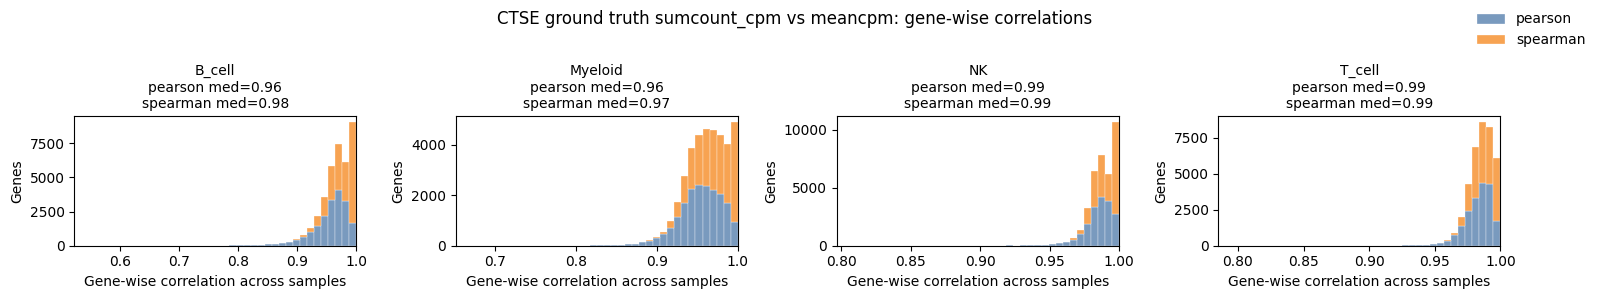

In [24]:
# Compare CTSE sumcount_cpm vs meancpm by gene-wise correlation across samples
ctse_cor = compute_ctse_gene_correlations(
    ctse_a_by_ct=ctse_sumcount_cpm,
    ctse_b_by_ct=ctse_meancpm_res["pseudobulk"],
    a_label="sumcount_cpm",
    b_label="meancpm",
    min_samples=3,
)

fig = plot_ctse_gene_correlation_histograms(
    ctse_cor,
    metrics=("pearson", "spearman"),
    bins=40,
    ncol=4,
    title="CTSE ground truth sumcount_cpm vs meancpm: gene-wise correlations",
    stacked=True,
)

plt.show()

In [27]:
# export metadata
cols = ['sample','disease_cov','pop_cov','Age','Sex','Study','SLE_status','ind_cov_cohort']
patient_info = adata.obs[cols].drop_duplicates().copy()
patient_info = patient_info.reset_index(drop = True)
patient_info.head()

,sample,disease_cov,pop_cov,Age,Sex,Study,SLE_status,ind_cov_cohort
0,sample_HC_546,Healthy,Asian,28.0,Female,LupCon,Healthy,HC-546L3
1,sample_FLARE006,Flare,European,34.0,Female,Flare,SLE,FLARE006L2
2,sample_1110_1110,Managed,European,71.0,Female,CLUES,SLE,1110_1110L3
3,sample_1479_1479,Managed,Asian,28.0,Female,CLUES,SLE,1479_1479L1_UCSF
4,sample_1334_1334,Managed,Asian,52.0,Female,CLUES,SLE,1334_1334L1_UCSF


In [28]:
n_cells = adata.obs["sample"].value_counts()
patient_info["nCells"] = patient_info["sample"].map(n_cells).astype(int)
patient_info.head()

,sample,disease_cov,pop_cov,Age,Sex,Study,SLE_status,ind_cov_cohort,nCells
0,sample_HC_546,Healthy,Asian,28.0,Female,LupCon,Healthy,HC-546L3,3178
1,sample_FLARE006,Flare,European,34.0,Female,Flare,SLE,FLARE006L2,3196
2,sample_1110_1110,Managed,European,71.0,Female,CLUES,SLE,1110_1110L3,6841
3,sample_1479_1479,Managed,Asian,28.0,Female,CLUES,SLE,1479_1479L1_UCSF,4005
4,sample_1334_1334,Managed,Asian,52.0,Female,CLUES,SLE,1334_1334L1_UCSF,5379


In [29]:
patient_info.to_csv(os.path.join(out_dir, "metadata", "sample_meta.txt"),sep="\t",index=False,)

In [30]:
ctse_sumcount_res['pseudobulk_meta'].head()

,cell_type_coarse,sample,nCells
0,T_cell,sample_HC_546,1209
1,T_cell,sample_FLARE006,1834
2,T_cell,sample_1110_1110,2785
3,T_cell,sample_1479_1479,1522
4,T_cell,sample_1334_1334,1338


In [31]:
ctse_sumcount_res['pseudobulk_meta'].to_csv(os.path.join(out_dir, "metadata", "ctse_meta.txt"),sep="\t",index=False,)

### PBMC_Perez2022 refined cell types

In [32]:
adata.obs['cell_type_refined'].value_counts()

cell_type_refined
CD4_T        296590
CD14_Mono    282014
CD8_T        212561
B_cell       120578
NK            79516
CD16_Mono     48053
DC            23199
Plasma_B       1277
Name: count, dtype: int64

In [33]:
sample_col = "sample"
ct_col = "cell_type_refined"
out_dir = "../Benchmarking_obj/PBMC_refined_Perez2022"

# Make folders
os.makedirs(os.path.join(out_dir, "bulk_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "frac_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "sumcount"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "meancpm"), exist_ok=True)

In [12]:
cellfrac = compute_cellfrac(adata.obs, sample_col=sample_col, ct_col=ct_col)
transcriptfrac = compute_transcriptfrac(adata, sample_col=sample_col, ct_col=ct_col)

In [14]:
cellfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_cellfrac.txt"),sep="\t",)
transcriptfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_transcriptfrac.txt"),sep="\t",)

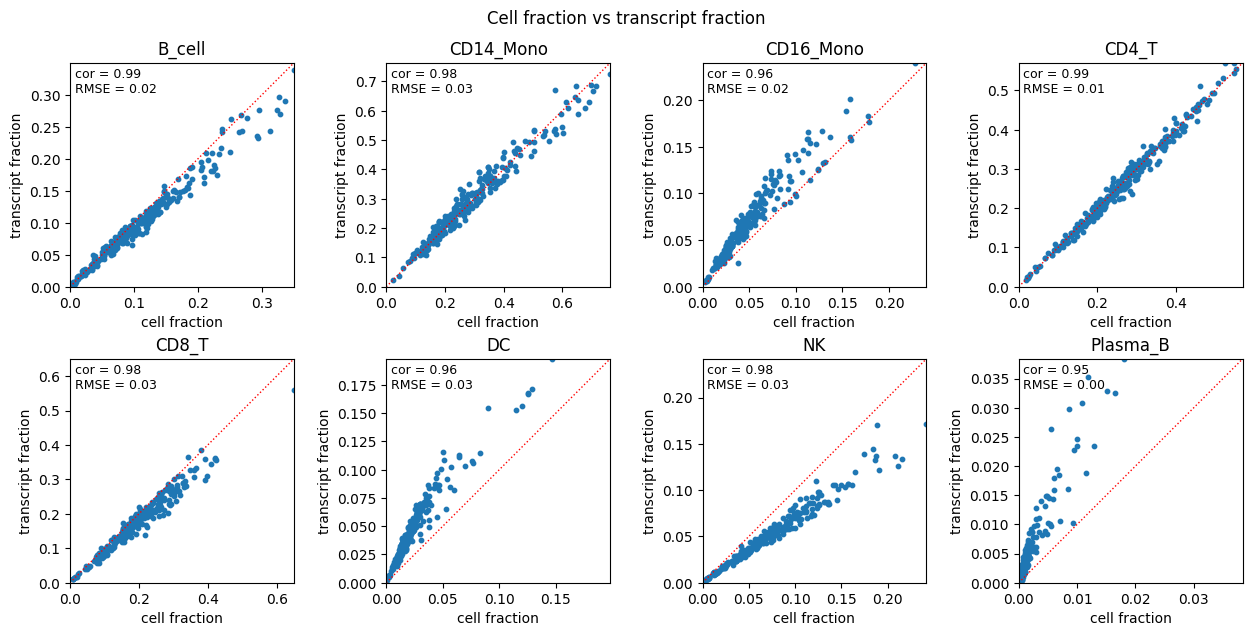

In [13]:
fig, summary, plot_data = plot_frac_comparison(
    cellfrac,
    transcriptfrac,
    title="Cell fraction vs transcript fraction",
    nrow=2,
    xlabel="cell fraction",
    ylabel="transcript fraction",
    return_data=True,
)

In [36]:
# bulk samples are essentially the same as in PBMC_Perez
bulk_sumcount.to_csv(os.path.join(out_dir, "bulk_input", "sumcount.txt"),sep="\t",)
bulk_wcpm.to_csv(os.path.join(out_dir, "bulk_input", "wcpm.txt"),sep="\t",float_format="%.2f",)

In [37]:
# ctse_truth from sum of counts
ctse_sumcount_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="count",
)

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
Two-key mode: returning dict keyed by 'cell_type_refined', with columns from 'sample'
Output contains 8 cell_type_refined groups
Each matrix shape: 18863 genes x 261 sample groups


In [38]:
# export ctse
for ct, mat in ctse_sumcount_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "sumcount", f"{ct}.txt.gz"),sep="\t",)

In [39]:
# Sanity check: bulk sumcount should equal the sum of CTSE sumcount across cell types
bulk_from_ctse = sum(ct_mat for ct_mat in ctse_sumcount_res["pseudobulk"].values())
bulk_from_ctse = bulk_from_ctse.loc[bulk_sumcount.index, bulk_sumcount.columns]
diff = bulk_sumcount.iloc[:5, :5] - bulk_from_ctse.iloc[:5, :5]
diff

,sample_1004_1004,sample_1014_1014,sample_1015_1015,sample_1019_1019,sample_1022_1022
RP11-34P13.7,0.0,0.0,0.0,0.0,0.0
AL627309.1,0.0,0.0,0.0,0.0,0.0
AP006222.2,0.0,0.0,0.0,0.0,0.0
RP4-669L17.10,0.0,0.0,0.0,0.0,0.0
RP5-857K21.4,0.0,0.0,0.0,0.0,0.0


In [40]:
# export cpm normalized sumcount ctse
ctse_sumcount_cpm_dir = Path(out_dir) / "ctse_truth" / "sumcount_cpm"
ctse_sumcount_cpm_dir.mkdir(parents=True, exist_ok=True)

ctse_sumcount_cpm = normalize_ctse_sumcount_to_cpm(
    ctse_sumcount_res["pseudobulk"],
    target_sum=1e6,
)

ctse_sumcount_cpm_paths = {}
for ct, mat in ctse_sumcount_cpm.items():
    ct_path = ctse_sumcount_cpm_dir / f"{ct}.txt.gz"
    mat.to_csv(ct_path, sep="\t", float_format="%.2f")
    ctse_sumcount_cpm_paths[ct] = ct_path

In [41]:
# ctse_truth from mean of cpm
ctse_meancpm_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="cpm",
)

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group
Two-key mode: returning dict keyed by 'cell_type_refined', with columns from 'sample'
Output contains 8 cell_type_refined groups
Each matrix shape: 18863 genes x 261 sample groups


In [42]:
# export ctse
for ct, mat in ctse_meancpm_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "meancpm", f"{ct}.txt.gz"),sep="\t",float_format="%.2f")

In [43]:
# Sanity check: bulk wcpm should equal the cell-fraction-weighted sum of CTSE meancpm across cell types
bulk_wcpm_from_ctse = compute_weighted_bulk_from_ct_profiles(ctse_meancpm_res["pseudobulk"], cellfrac,log2_transform=False,)
bulk_wcpm_from_ctse = bulk_wcpm_from_ctse.loc[bulk_wcpm.index,bulk_wcpm.columns,]
diff = bulk_wcpm.iloc[:5, :5] - bulk_wcpm_from_ctse.iloc[:5, :5]
diff # almost identical

,sample_1004_1004,sample_1014_1014,sample_1015_1015,sample_1019_1019,sample_1022_1022
RP11-34P13.7,5.551115e-17,0.000000e+00,0.000000e+00,2.775558e-17,-5.551115e-17
AL627309.1,4.440892e-16,0.000000e+00,0.000000e+00,-2.220446e-16,0.000000e+00
AP006222.2,-8.881784e-16,8.881784e-16,8.881784e-16,-8.881784e-16,0.000000e+00
RP4-669L17.10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
RP5-857K21.4,0.000000e+00,-1.387779e-17,0.000000e+00,0.000000e+00,0.000000e+00


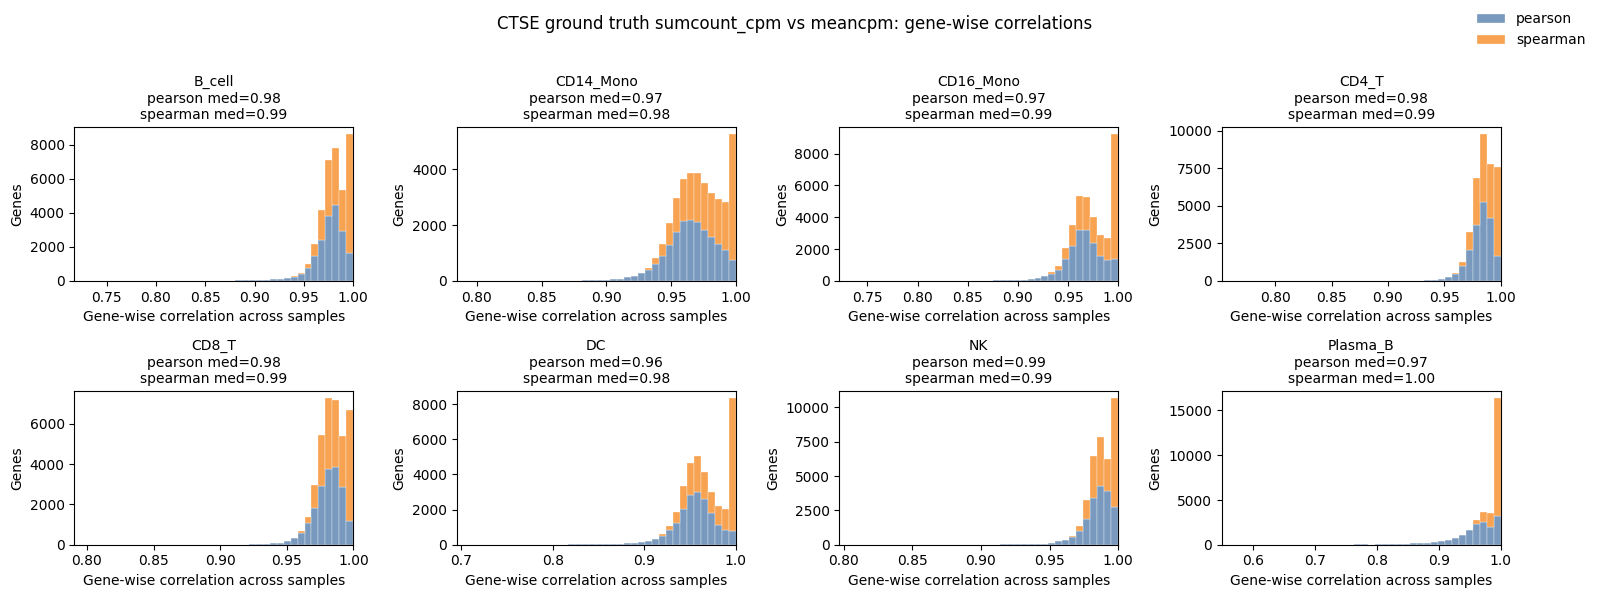

In [44]:
# Compare CTSE sumcount_cpm vs meancpm by gene-wise correlation across samples
ctse_cor = compute_ctse_gene_correlations(
    ctse_a_by_ct=ctse_sumcount_cpm,
    ctse_b_by_ct=ctse_meancpm_res["pseudobulk"],
    a_label="sumcount_cpm",
    b_label="meancpm",
    min_samples=3,
)

fig = plot_ctse_gene_correlation_histograms(
    ctse_cor,
    metrics=("pearson", "spearman"),
    bins=40,
    ncol=4,
    title="CTSE ground truth sumcount_cpm vs meancpm: gene-wise correlations",
    stacked=True,
)

plt.show()

## ROSMAP_AD92_Xiong2023

In [ ]:
# paper: https://www.cell.com/cell/fulltext/S0092-8674(23)00974-1
# snRNA data downloaded from https://cells.ucsc.edu/?ds=ad-aging-brain 
# under "AD and Aging Prefrontal Cortex Across 92 Individuals" identifier
# important note: all samples from Brain_Xiong2023 can be found in Brain_Mathys2023
# but because the source snRNA data are downloaded separately, and apparently underwent different preprocessing
# pseudobulk data and truthFrac for the same sample can be slightly different

In [2]:
dataset_path = '../../../InstaPrismExtension/scRNA_resource/ROSMAP/AD92_Xiong2023/'

In [3]:
os.listdir(dataset_path)

['matrix.mtx.gz',
 'features.tsv.gz',
 'barcodes.tsv.gz',
 'meta.tsv',
 'README',
 'snATAC_seq']

In [6]:
%%time
mtx_file = os.path.join(dataset_path,"matrix.mtx.gz")
matrix = mmread(mtx_file)

CPU times: user 1min 47s, sys: 3.05 s, total: 1min 50s
Wall time: 2min 5s


In [7]:
barcodes = pd.read_csv(os.path.join(dataset_path,"barcodes.tsv.gz"), header=None, sep="\t")  
scMeta = pd.read_csv(os.path.join(dataset_path,"meta.tsv"), header=0, sep="\t") 
genes = pd.read_csv(os.path.join(dataset_path,"features.tsv.gz"), header=None, sep="\t")  

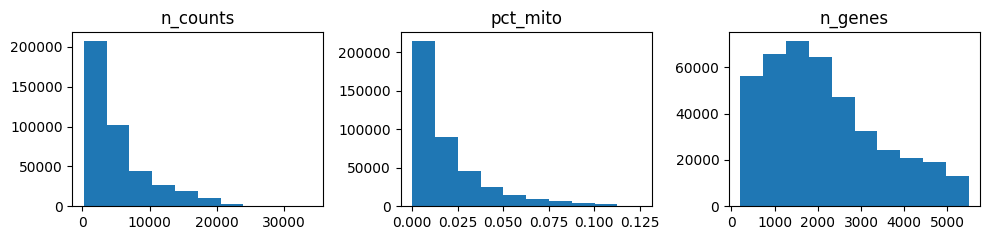

In [8]:
plt.figure(figsize=(10,2.5))
for i, col in enumerate(['n_counts', 'pct_mito', 'n_genes'], 1):
    plt.subplot(1,3,i); plt.hist(scMeta[col].dropna()); plt.title(col)
plt.tight_layout()
plt.show()

In [9]:
adata = ad.AnnData(X=matrix.T.tocsc())

In [10]:
adata.obs = scMeta.set_index(scMeta.columns[0]) 
adata.var_names = genes[0].values
adata.obs['sample'] = adata.obs['Individual'].str.replace('-', '_', regex=False)

In [11]:
adata

AnnData object with n_obs × n_vars = 414964 × 33538
    obs: 'Individual', 'Batch', 'Celltype', 'Subcelltype', 'msex', 'ADdiag3types', 'n_counts', 'n_genes', 'pct_mito', 'pct_ribo', 'sample'

In [12]:
# since this is snRNA, will relatively relax the filtering standard
sum((adata.obs['n_counts'] >= 500) & 
     (adata.obs['n_genes'] >= 300) &
    (adata.obs['pct_mito'] <= 10)  &
    (adata.obs['pct_ribo'] <= 10))

404378

In [13]:
# qc metrics for genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, percent_top=[20], log1p=True
)

In [15]:
# qc
adata_processed = adata[
    (adata.obs['n_counts'] >= 500) &
    (adata.obs['n_genes'] >= 300) &
    (adata.obs['pct_mito'] <= 10) &
    (adata.obs['pct_ribo'] <= 10),
    adata.var['n_cells_by_counts'] >= 100
].copy()

In [26]:
adata_processed

AnnData object with n_obs × n_vars = 404378 × 26019
    obs: 'Individual', 'Batch', 'Celltype', 'Subcelltype', 'msex', 'ADdiag3types', 'n_counts', 'n_genes', 'pct_mito', 'pct_ribo', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [16]:
adata_processed.obs.head()

,Individual,Batch,Celltype,Subcelltype,msex,ADdiag3types,n_counts,n_genes,pct_mito,pct_ribo,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
cellId,,,,,,,,,,,,,,,,,,,
SM_171013Tsa_AAACCTGGTCGCATCG-42,ROSMAP-10859,SM_171013Tsa,Exc,Exc L3-5 RORB PLCH1,1,lateAD,3905,2111,0.043790,0.006914,ROSMAP_10859,2331,7.754482,4442.0,8.399085,13.867627,171.0,5.147494,3.849617
SM_171013Tsa_AAACCTGGTTGCCTCT-42,ROSMAP-10859,SM_171013Tsa,Exc,Exc L2-3 CBLN2 LINC02306,1,lateAD,2966,1770,0.063722,0.007755,ROSMAP_10859,1889,7.544332,3230.0,8.080547,13.436533,189.0,5.247024,5.851393
SM_171013Tsa_AAACGGGAGGTAAACT-42,ROSMAP-10859,SM_171013Tsa,Mic,Mic P2RY12,1,lateAD,1584,1143,0.002525,0.008207,ROSMAP_10859,1264,7.142827,1834.0,7.514800,14.176663,4.0,1.609438,0.218103
SM_171013Tsa_AAACGGGTCCCTGACT-42,ROSMAP-10859,SM_171013Tsa,Oli,Oli OPALIN,1,lateAD,1232,832,0.020292,0.008929,ROSMAP_10859,905,6.809039,1401.0,7.245655,16.059957,25.0,3.258097,1.784440
SM_171013Tsa_AAAGATGAGAGTACAT-42,ROSMAP-10859,SM_171013Tsa,Exc,Exc L6 THEMIS NFIA,1,lateAD,4969,2396,0.085128,0.003622,ROSMAP_10859,2617,7.870166,5609.0,8.632306,18.559458,423.0,6.049733,7.541451


In [17]:
adata_processed.obs['Celltype'].value_counts()

Celltype
Exc    166066
Oli    117243
Inh     60541
Ast     26748
Opc     19122
Mic     12812
Vas      1846
Name: count, dtype: int64

In [18]:
sample_col = "sample"
ct_col = "Celltype"
out_dir = "../Benchmarking_obj/ROSMAP_AD92_Xiong2023"

# Make folders
os.makedirs(os.path.join(out_dir, "bulk_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "frac_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "sumcount"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "meancpm"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "metadata"), exist_ok=True)

### truthfrac from snRNA

In [27]:
cellfrac = compute_cellfrac(adata_processed.obs, sample_col=sample_col, ct_col=ct_col)
transcriptfrac = compute_transcriptfrac(adata_processed, sample_col=sample_col, ct_col=ct_col)

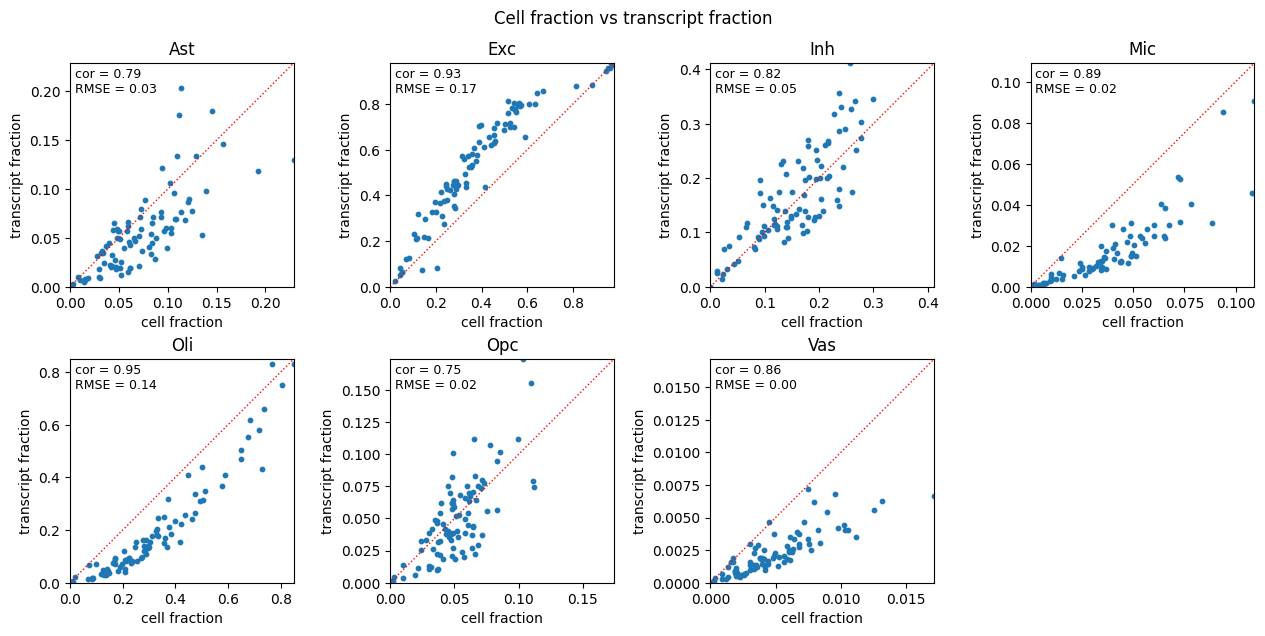

In [28]:
fig, summary, plot_data = plot_frac_comparison(
    cellfrac,
    transcriptfrac,
    title="Cell fraction vs transcript fraction",
    nrow=2,
    xlabel="cell fraction",
    ylabel="transcript fraction",
    return_data=True,
)

In [29]:
cellfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_cellfrac.txt"),sep="\t",)
transcriptfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_transcriptfrac.txt"),sep="\t",)

### pseudobulk from counts

In [30]:
# bulk samples from sum of counts
# note: transcriptfrac is a more relevant cell type frac estimate for this pseudobulk profile
bulk_sumcount = build_ct_pseudobulk_profiles(
    adata_processed,
    ct_group_keys=sample_col,
    pseudobulk_type="count",
)["pseudobulk"]

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
One-key mode: returning gene x sample DataFrame
Output pseudobulk shape: 26019 genes x 92 groups


In [31]:
bulk_sumcount.to_csv(os.path.join(out_dir, "bulk_input", "sumcount.txt"),sep="\t",)

In [33]:
# ctse_truth from sum of counts
ctse_sumcount_res = build_ct_pseudobulk_profiles(
    adata_processed,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="count",
)

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
Two-key mode: returning dict keyed by 'Celltype', with columns from 'sample'
Output contains 7 Celltype groups
Each matrix shape: 26019 genes x 92 sample groups


In [34]:
# export ctse
for ct, mat in ctse_sumcount_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "sumcount", f"{ct}.txt.gz"),sep="\t",)

In [35]:
# Sanity check: bulk sumcount should equal the sum of CTSE sumcount across cell types
bulk_from_ctse = sum(ct_mat for ct_mat in ctse_sumcount_res["pseudobulk"].values())
bulk_from_ctse = bulk_from_ctse.loc[bulk_sumcount.index, bulk_sumcount.columns]
diff = bulk_sumcount.iloc[:5, :5] - bulk_from_ctse.iloc[:5, :5]
diff

,ROSMAP_10859,ROSMAP_12078,ROSMAP_14589,ROSMAP_15050,ROSMAP_15253
AL627309.1,0.0,0.0,0.0,0.0,0.0
AC114498.1,0.0,0.0,0.0,0.0,0.0
AL669831.5,0.0,0.0,0.0,0.0,0.0
FAM87B,0.0,0.0,0.0,0.0,0.0
LINC00115,0.0,0.0,0.0,0.0,0.0


In [36]:
# export cpm normalized sumcount ctse
ctse_sumcount_cpm_dir = Path(out_dir) / "ctse_truth" / "sumcount_cpm"
ctse_sumcount_cpm_dir.mkdir(parents=True, exist_ok=True)

ctse_sumcount_cpm = normalize_ctse_sumcount_to_cpm(
    ctse_sumcount_res["pseudobulk"],
    target_sum=1e6,
)

ctse_sumcount_cpm_paths = {}
for ct, mat in ctse_sumcount_cpm.items():
    ct_path = ctse_sumcount_cpm_dir / f"{ct}.txt.gz"
    mat.to_csv(ct_path, sep="\t", float_format="%.2f")
    ctse_sumcount_cpm_paths[ct] = ct_path

### pseudobulk from cpm

In [42]:
# bulk samples from mean of cpm values per sample
# this is essential the same as a weighted sum of ctse cpm values, where weight is cellfrac
bulk_wcpm = build_ct_pseudobulk_profiles(
    adata_processed,
    ct_group_keys=sample_col,
    pseudobulk_type="cpm",
)["pseudobulk"]

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group
One-key mode: returning gene x sample DataFrame
Output pseudobulk shape: 26019 genes x 92 groups


In [43]:
bulk_wcpm.to_csv(os.path.join(out_dir, "bulk_input", "wcpm.txt"),sep="\t",float_format="%.2f",)

In [44]:
# ctse_truth from mean of cpm
ctse_meancpm_res = build_ct_pseudobulk_profiles(
    adata_processed,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="cpm",
)

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group
Two-key mode: returning dict keyed by 'Celltype', with columns from 'sample'
Output contains 7 Celltype groups
Each matrix shape: 26019 genes x 92 sample groups


In [45]:
# export ctse
for ct, mat in ctse_meancpm_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "meancpm", f"{ct}.txt.gz"),sep="\t",float_format="%.2f")

In [46]:
# Sanity check: bulk wcpm should equal the cell-fraction-weighted sum of CTSE meancpm across cell types
bulk_wcpm_from_ctse = compute_weighted_bulk_from_ct_profiles(ctse_meancpm_res["pseudobulk"], cellfrac,log2_transform=False,)
bulk_wcpm_from_ctse = bulk_wcpm_from_ctse.loc[bulk_wcpm.index,bulk_wcpm.columns,]
diff = bulk_wcpm.iloc[:5, :5] - bulk_wcpm_from_ctse.iloc[:5, :5]
diff # almost identical

,ROSMAP_10859,ROSMAP_12078,ROSMAP_14589,ROSMAP_15050,ROSMAP_15253
AL627309.1,0.000000e+00,1.776357e-15,-6.217249e-15,0.000000e+00,5.329071e-15
AC114498.1,0.000000e+00,0.000000e+00,2.775558e-17,2.775558e-17,2.775558e-17
AL669831.5,-1.421085e-14,2.131628e-14,7.105427e-15,-2.842171e-14,-7.105427e-15
FAM87B,0.000000e+00,0.000000e+00,0.000000e+00,-6.938894e-18,0.000000e+00
LINC00115,0.000000e+00,0.000000e+00,-2.220446e-16,0.000000e+00,1.110223e-16


### ctse truth comparison cpm vs sumcounts_cpm

In [47]:
ctse_cor = compute_ctse_gene_correlations(
    ctse_a_by_ct=ctse_sumcount_cpm,
    ctse_b_by_ct=ctse_meancpm_res["pseudobulk"],
    a_label="sumcount_cpm",
    b_label="meancpm",
    min_samples=3,
)

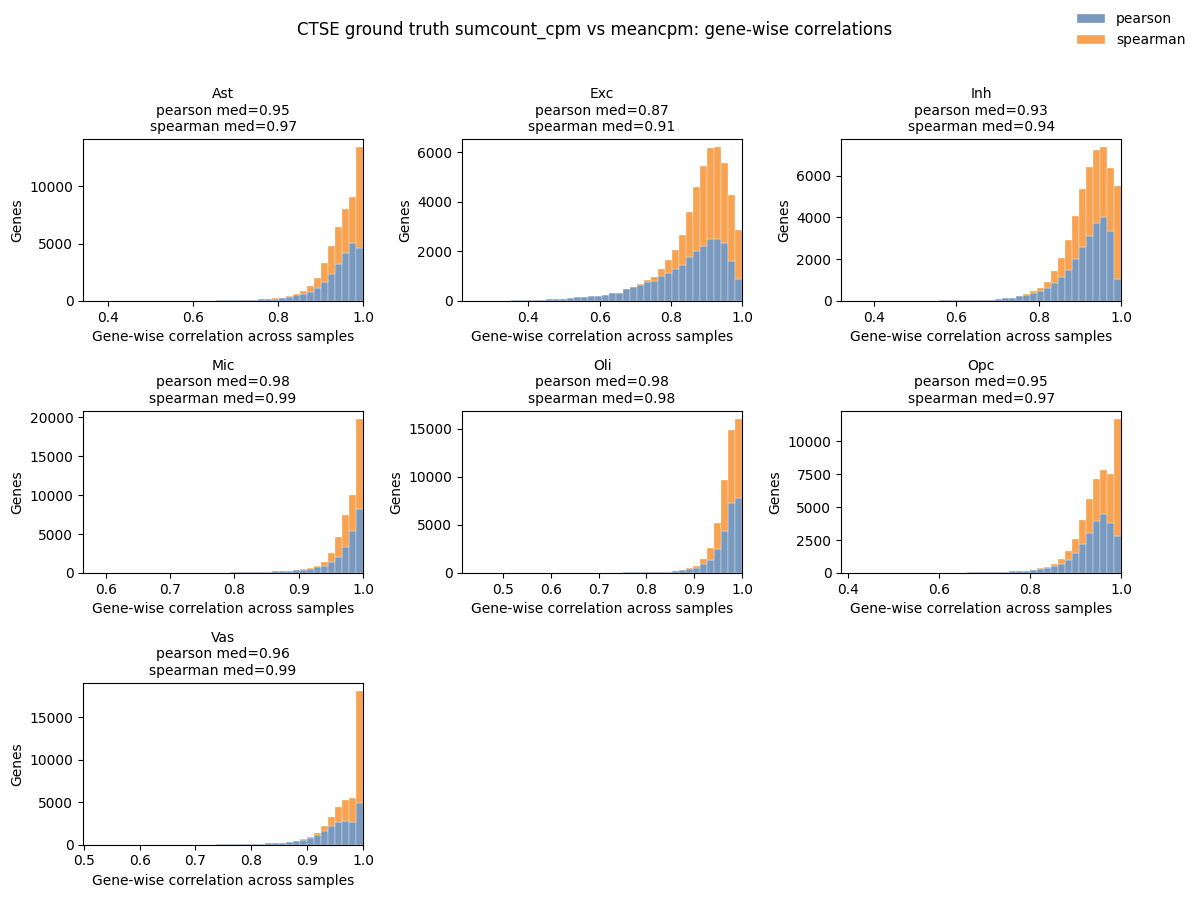

In [48]:
# Compare CTSE sumcount_cpm vs meancpm by gene-wise correlation across samples
fig = plot_ctse_gene_correlation_histograms(
    ctse_cor,
    metrics=("pearson", "spearman"),
    bins=40,
    ncol=3,
    title="CTSE ground truth sumcount_cpm vs meancpm: gene-wise correlations",
    stacked=True,
)

plt.show()

### metadata

In [49]:
cols = [
    'sample','ADdiag3types'
]

sample_meta = adata.obs[cols].drop_duplicates().copy()
sample_meta = sample_meta.reset_index(drop = True)
sample_meta.head()

,sample,ADdiag3types
0,ROSMAP_10859,lateAD
1,ROSMAP_40301,earlyAD
2,ROSMAP_18705,nonAD
3,ROSMAP_42444,nonAD
4,ROSMAP_43150,nonAD


In [50]:
n_cells = adata.obs["sample"].value_counts()
sample_meta["nCells"] = sample_meta["sample"].map(n_cells).astype(int)
sample_meta

,sample,ADdiag3types,nCells
0,ROSMAP_10859,lateAD,3351
1,ROSMAP_40301,earlyAD,4253
2,ROSMAP_18705,nonAD,4126
3,ROSMAP_42444,nonAD,9183
4,ROSMAP_43150,nonAD,2250
...,...,...,...
87,ROSMAP_74690,nonAD,10987
88,ROSMAP_20769,nonAD,4854
89,ROSMAP_44788,nonAD,7653
90,ROSMAP_34449,nonAD,5176


In [51]:
sample_meta.to_csv(os.path.join(out_dir, "metadata", "sample_meta.txt"),sep="\t",index=False,)

In [52]:
ctse_sumcount_res['pseudobulk_meta'].to_csv(os.path.join(out_dir, "metadata", "ctse_meta.txt"),sep="\t",index=False,)

## ROSMAP_AD430_Mathys2023

In [ ]:
# paper: https://www.cell.com/cell/fulltext/S0092-8674(23)00973-X
# snRNA data downloaded from https://cells.ucsc.edu/?ds=ad-aging-brain (already gene/cell filtered)
# under "AD and Aging Prefrontal Cortex Across 427 individuals" identifier
# individual meta data (individual_metadata_deidentified.tsv) downloaded from https://compbio.mit.edu/ad_aging_brain/
# under "AD and Aging Prefrontal Cortex Across 427 individuals" identifier

# important note: all samples from Brain_Xiong2023 actually part of samples from Brain_Mathys2023
# however, two adata have different number of genes and different number of cells available 
# therefore, for the same sampleID, their pseudobulk values and truthFrac can be slightly different!

In [4]:
dataset_path = '../../../InstaPrismExtension/scRNA_resource/ROSMAP/AD430_Mathys2023/'

In [5]:
os.listdir(dataset_path)

['PIIS009286742300973X.pdf',
 'ad430_features.tsv.gz',
 'ad430_barcodes.tsv.gz',
 'meta.tsv',
 'README',
 'ad430_matrix.mtx.gz',
 'individual_metadata_deidentified.tsv']

In [6]:
%%time
mtx_file = os.path.join(dataset_path,"ad430_matrix.mtx.gz")
matrix = mmread(mtx_file)

CPU times: user 28min 13s, sys: 1min 46s, total: 30min
Wall time: 15min 41s


In [7]:
matrix.shape

(18934, 2327742)

In [8]:
scMeta = pd.read_csv(os.path.join(dataset_path,"meta.tsv"), header=0, sep="\t") 
genes = pd.read_csv(os.path.join(dataset_path,"ad430_features.tsv.gz"), header=None, sep="\t")  

In [9]:
sp.issparse(matrix)

True

In [10]:
scMeta.head(3)

,cellName,Batch,n_counts,percent_ribo,percent_mito,n_genes,Dataset,Major_Cell_Type,Cell_Type,Individual
0,SM_171013Tsa_AAACGGGAGATCCCGC-1,SM_171013Tsa,526,0.024715,0.032319,444,SM_171013Tsa-1,Exc,Exc NRGN,ROSMAP-52226
1,SM_171013Tsa_AAATGCCTCCAATGGT-1,SM_171013Tsa,15803,0.007657,0.006454,5359,SM_171013Tsa-1,Exc,Exc L3-4 RORB CUX2,ROSMAP-52226
2,SM_171013Tsa_AACCATGTCAGTGCAT-1,SM_171013Tsa,666,0.025526,0.070571,530,SM_171013Tsa-1,Exc,Exc RELN CHD7,ROSMAP-52226


In [11]:
%%time
adata = ad.AnnData(X=matrix.T.tocsc())

CPU times: user 6min 59s, sys: 1h 20min 7s, total: 1h 27min 6s
Wall time: 1h 28min 37s


In [12]:
adata

AnnData object with n_obs × n_vars = 2327742 × 18934

In [13]:
adata.obs = scMeta.set_index(scMeta.columns[0]) 
adata.var_names = genes[0].values

In [14]:
adata.obs['sample'] = adata.obs['Individual'].str.replace('-', '_', regex=False)

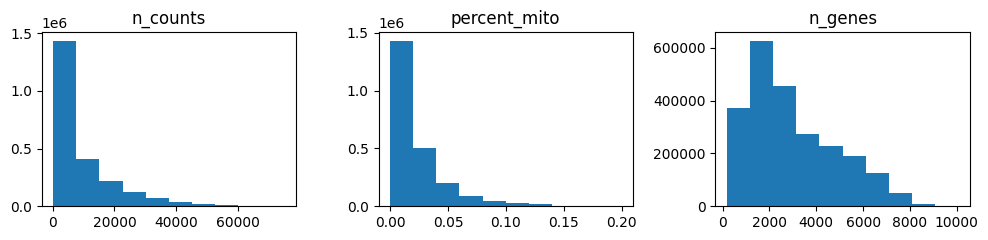

In [15]:
plt.figure(figsize=(10,2.5))
for i, col in enumerate(['n_counts', 'percent_mito', 'n_genes'], 1):
    plt.subplot(1,3,i); plt.hist(adata.obs[col].dropna()); plt.title(col)
plt.tight_layout()
plt.show()

In [16]:
sample_col = "sample"
ct_col = "Major_Cell_Type"
out_dir = "../Benchmarking_obj/ROSMAP_AD430_Mathys2023"

# Make folders
os.makedirs(os.path.join(out_dir, "bulk_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "frac_input"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "sumcount"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "ctse_truth", "meancpm"), exist_ok=True)
os.makedirs(os.path.join(out_dir, "metadata"), exist_ok=True)

### truthfrac from snRNA

In [17]:
cellfrac = compute_cellfrac(adata.obs, sample_col=sample_col, ct_col=ct_col)
transcriptfrac = compute_transcriptfrac(adata, sample_col=sample_col, ct_col=ct_col)

In [18]:
cellfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_cellfrac.txt"),sep="\t",)
transcriptfrac.to_csv(os.path.join(out_dir, "frac_input", "truth_transcriptfrac.txt"),sep="\t",)

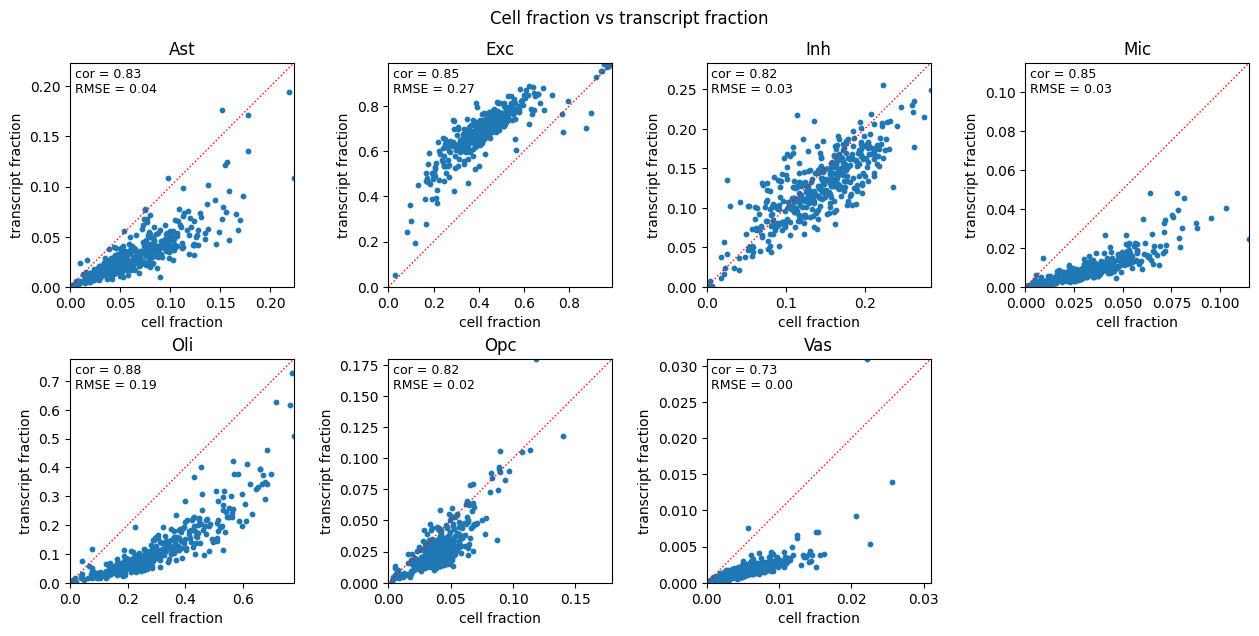

In [19]:
fig, summary, plot_data = plot_frac_comparison(
    cellfrac,
    transcriptfrac,
    title="Cell fraction vs transcript fraction",
    nrow=2,
    xlabel="cell fraction",
    ylabel="transcript fraction",
    return_data=True,
)

### pseudobulk from counts

In [21]:
%%time
# bulk samples from sum of counts
# note: transcriptfrac is a more relevant cell type frac estimate for this pseudobulk profile
bulk_sumcount = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=sample_col,
    pseudobulk_type="count",
)["pseudobulk"]

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
One-key mode: returning gene x sample DataFrame
Output pseudobulk shape: 18934 genes x 427 groups
CPU times: user 26min 30s, sys: 3h 46min 12s, total: 4h 12min 42s
Wall time: 4h 12min 50s


In [22]:
bulk_sumcount.to_csv(os.path.join(out_dir, "bulk_input", "sumcount.txt"),sep="\t",)

In [24]:
%%time
# ctse_truth from sum of counts
ctse_sumcount_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="count",
)

adata.X detected as: count
Using aggregation: sum
Output meaning: raw count sum per pseudobulk group
Two-key mode: returning dict keyed by 'Major_Cell_Type', with columns from 'sample'
Output contains 7 Major_Cell_Type groups
Each matrix shape: 18934 genes x 427 sample groups
CPU times: user 26min 38s, sys: 2h 2min 34s, total: 2h 29min 13s
Wall time: 2h 29min 59s


In [25]:
# export ctse
for ct, mat in ctse_sumcount_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "sumcount", f"{ct}.txt.gz"),sep="\t",)

In [34]:
# export cpm normalized sumcount ctse
ctse_sumcount_cpm_dir = Path(out_dir) / "ctse_truth" / "sumcount_cpm"
ctse_sumcount_cpm_dir.mkdir(parents=True, exist_ok=True)

ctse_sumcount_cpm = normalize_ctse_sumcount_to_cpm(
    ctse_sumcount_res["pseudobulk"],
    target_sum=1e6,
)

ctse_sumcount_cpm_paths = {}
for ct, mat in ctse_sumcount_cpm.items():
    ct_path = ctse_sumcount_cpm_dir / f"{ct}.txt.gz"
    mat.to_csv(ct_path, sep="\t", float_format="%.2f")
    ctse_sumcount_cpm_paths[ct] = ct_path

### pseudobulk from cpm

In [28]:
%%time
# ctse_truth from mean of cpm
ctse_meancpm_res = build_ct_pseudobulk_profiles(
    adata,
    ct_group_keys=[ct_col, sample_col],
    pseudobulk_type="cpm",
)
# export ctse
for ct, mat in ctse_meancpm_res['pseudobulk'].items():
    mat.to_csv(os.path.join(out_dir, "ctse_truth", "meancpm", f"{ct}.txt.gz"),sep="\t",float_format="%.2f")

adata.X detected as: count
Normalizing each cell to CPM with target_sum=1e+06
Using aggregation: mean
Output meaning: mean CPM per pseudobulk group
Two-key mode: returning dict keyed by 'Major_Cell_Type', with columns from 'sample'
Output contains 7 Major_Cell_Type groups
Each matrix shape: 18934 genes x 427 sample groups
CPU times: user 33min 48s, sys: 4h 48min 5s, total: 5h 21min 53s
Wall time: 5h 22min 13s


In [29]:
bulk_wcpm_from_ctse = compute_weighted_bulk_from_ct_profiles(ctse_meancpm_res["pseudobulk"], cellfrac,log2_transform=False,)

In [32]:
bulk_wcpm_from_ctse.to_csv(os.path.join(out_dir, "bulk_input", "wcpm.txt"),sep="\t",float_format="%.2f",)

### ctse truth comparison cpm vs sumcounts_cpm

In [35]:
ctse_cor = compute_ctse_gene_correlations(
    ctse_a_by_ct=ctse_sumcount_cpm,
    ctse_b_by_ct=ctse_meancpm_res["pseudobulk"],
    a_label="sumcount_cpm",
    b_label="meancpm",
    min_samples=3,
)

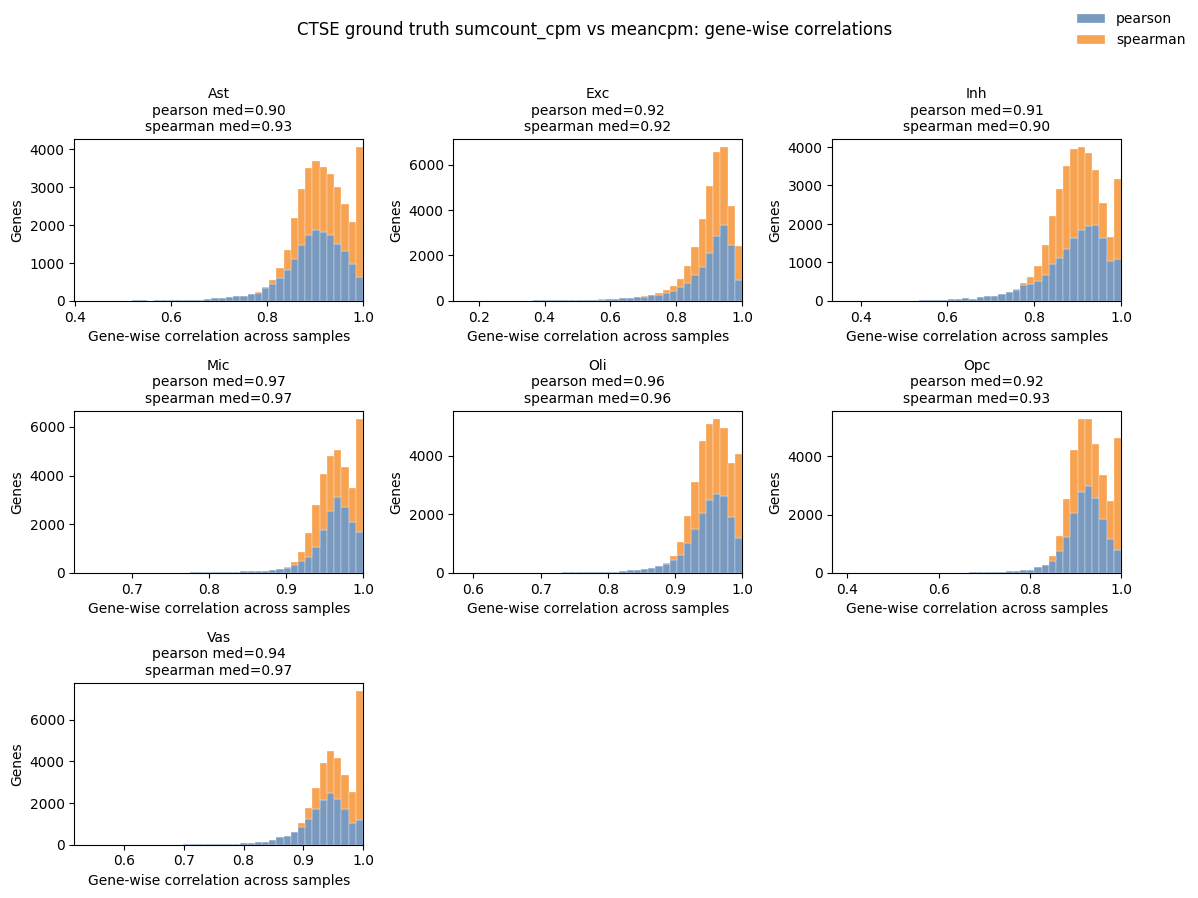

In [36]:
# Compare CTSE sumcount_cpm vs meancpm by gene-wise correlation across samples
fig = plot_ctse_gene_correlation_histograms(
    ctse_cor,
    metrics=("pearson", "spearman"),
    bins=40,
    ncol=3,
    title="CTSE ground truth sumcount_cpm vs meancpm: gene-wise correlations",
    stacked=True,
)

plt.show()

### metadata

In [37]:
patient_info = adata.obs[['sample','Dataset']].drop_duplicates().copy()
patient_info = patient_info.reset_index(drop = True)
nCells_df = adata.obs['sample'].value_counts()
patient_info = patient_info.merge(
    nCells_df.rename('nCells'),
    on='sample',
    how='left'
)
patient_info.head()

,sample,Dataset,nCells
0,ROSMAP_52226,SM_171013Tsa-1,462
1,ROSMAP_72912,SM_171013Tsa-2,261
2,ROSMAP_66835,SM_171013Tsa-3,1131
3,ROSMAP_90257,SM_171013Tsa-4,1689
4,ROSMAP_38740,SM_171013Tsa-5,2688


In [39]:
# append more individual information
individual_meta = pd.read_csv(os.path.join(dataset_path,'individual_metadata_deidentified.tsv'),sep = '\t')
individual_meta['sample'] = individual_meta['subject'].str.replace('-', '_', regex=False)
individual_meta.head()

,subject,msex,age_death,pmi,race,Pathologic_diagnosis_of_AD,sample
0,ROSMAP-10132,0,90+,7.0,1,yes,ROSMAP_10132
1,ROSMAP-10643,0,90+,13.0,1,yes,ROSMAP_10643
2,ROSMAP-10859,1,"(80,85]",14.0,2,yes,ROSMAP_10859
3,ROSMAP-12078,1,"(85,90]",3.0,1,yes,ROSMAP_12078
4,ROSMAP-12256,1,"(85,90]",4.0,1,yes,ROSMAP_12256


In [40]:
patient_info = patient_info.merge(individual_meta, on='sample', how='left')

In [41]:
patient_info.head()

,sample,Dataset,nCells,subject,msex,age_death,pmi,race,Pathologic_diagnosis_of_AD
0,ROSMAP_52226,SM_171013Tsa-1,462,ROSMAP-52226,1,"(80,85]",1.0,1,no
1,ROSMAP_72912,SM_171013Tsa-2,261,ROSMAP-72912,1,"(85,90]",4.0,1,yes
2,ROSMAP_66835,SM_171013Tsa-3,1131,ROSMAP-66835,1,"(85,90]",9.0,2,no
3,ROSMAP_90257,SM_171013Tsa-4,1689,ROSMAP-90257,1,"(85,90]",18.0,1,yes
4,ROSMAP_38740,SM_171013Tsa-5,2688,ROSMAP-38740,0,90+,4.0,1,no


In [42]:
patient_info.to_csv(os.path.join(out_dir, "metadata", "sample_meta.txt"),sep="\t",index=False,)

In [43]:
ctse_sumcount_res['pseudobulk_meta'].to_csv(os.path.join(out_dir, "metadata", "ctse_meta.txt"),sep="\t",index=False,)